# Exploratory Data Analysis

## 1. Setup

In [28]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Display settings — readable tables and figures.
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(context="notebook", style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

# Reproducibility: any later random subsampling goes through this generator.
RNG = np.random.default_rng(42)

# Project paths. Edit ROOT if your local layout differs.
ROOT  = Path.cwd()
DATA  = ROOT / "Data"
SMART = DATA / "SmartSeq"
DROP  = DATA / "DropSeq"

# Quick sanity-check that the expected data folders are visible from this notebook.
for label, p in [("ROOT", ROOT), ("DATA", DATA), ("SMART", SMART), ("DROP", DROP)]:
    print(f"{label:<6} : exists={p.exists()}   {p}")

ROOT   : exists=True   /Users/monahusein/Desktop/bocconi/ai lab
DATA   : exists=True   /Users/monahusein/Desktop/bocconi/ai lab/Data
SMART  : exists=True   /Users/monahusein/Desktop/bocconi/ai lab/Data/SmartSeq
DROP   : exists=True   /Users/monahusein/Desktop/bocconi/ai lab/Data/DropSeq


## 2. Exploratory Data Analysis — SmartSeq

We begin the EDA with the **SmartSeq** experiments. SmartSeq is a *plate-based*, full-length single-cell protocol: each cell is sequenced from end to end with a relatively large number of reads, but only a few hundred cells per cell line are profiled. The trade-off is that we get **deep per-cell information** at the cost of **few cells**. This is the opposite of DropSeq, which we will turn to in the next section.

For each of the two SmartSeq cell lines (`MCF7` and `HCC1806`) the project actually supplies five files:

| Stage | Description |
| --- | --- |
| `unfilt` | Raw count matrix straight from `featureCounts`. No filtering, no normalisation. |
| `filt`   | Same matrix after the curators removed low-quality cells. |
| `norm_train` | Filtered, normalised, restricted to the 3 000 most variable genes, split into a labelled training matrix. |
| `norm_test`  | The corresponding held-out matrix, **anonymised**: the cells are renumbered `"1"`, `"2"`, … so the condition cannot be read off the column header. |
| `meta`   | Metadata TSV with one row per cell, carrying the PCR plate, well position, sequencing index, and the experimental `Condition` (`Hypo` / `Normo`). |

> **Scope of this section.** The EDA below works entirely with the **unfiltered** count matrices and the SmartSeq **metadata**. The filtered and normalised matrices are products of preprocessing decisions that the data curators have already made for us, and inspecting them at this stage would conflate "what the data actually looks like" with "what is left after someone else's filter". By restricting our analysis to the raw, unfiltered data, we can observe the true distributions, the actual sparsity, the outlier behaviour and the dynamic range of the underlying measurement — exactly the properties that justify (or call into question) the curators' subsequent choices. The filtered and normalised matrices will be revisited in the modelling notebook, where they become the working substrate for training the classifier.

### 2.1 Loading data and metadata

The unfiltered count matrices are stored as **whitespace-separated `.txt` files** (despite the extension — they use one or more spaces, not tabs, as a delimiter, and pandas needs to be told that explicitly via `sep=r"\s+"` with the python parser engine). The **first column is the gene symbol** (used as the row index) and the **remaining columns are individual cells**. The cell-condition labels are encoded inside the column names themselves, but the two technologies do it differently and we have to handle both:

* **SmartSeq** column names look like `output.STAR.<plate>_<well>_<Hypo|Norm>_S###_Aligned.sortedByCoord.out.bam` — note the **short** form `Hypo` / `Norm`, *not* the full words.
* **DropSeq** column names (used in section 3) look like `<barcode>_Hypoxia` or `<barcode>_Normoxia` — the **full** form.

Our `parse_condition_from_columns` helper recognises both forms with a single regex and normalises every match to the canonical full-form label (`Hypoxia` / `Normoxia`). The alternation lists the longer alternatives first so that `Normoxia` wins over `Norm` when both could match the same string — an ordering that matters in regular-expression semantics.

The SmartSeq metadata, in contrast to the count matrices, is a true **tab-separated** file (`.tsv`). We use a separate `load_smartseq_meta` helper for it: it uses the `Filename` column as the row index (so the metadata's index is directly comparable to the count matrix's column index), strips whitespace from the column headers, and adds a `condition_full` column that mirrors the same `Hypoxia` / `Normoxia` vocabulary used everywhere else.

In [29]:
def load_matrix(path: Path) -> pd.DataFrame:
    """Load a gene × cell expression matrix with gene symbols as the row index.

    Note on delimiters: the count matrices in this project use *whitespace*
    (one or more spaces) as a delimiter, not tabs. The python engine of
    pandas handles this robustly via sep=r"\s+". The metadata TSVs are tab
    delimited and are loaded by `load_smartseq_meta` below.
    """
    return pd.read_csv(path, sep=r"\s+", engine="python", index_col=0)


# Longer alternatives listed first so "Hypoxia"/"Normoxia" win over "Hypo"/"Norm"
# when both could match within the same string.
COND_RE = re.compile(r"(Hypoxia|Normoxia|Hypo|Norm)")
_COND_MAP = {
    "Hypo":     "Hypoxia",
    "Hypoxia":  "Hypoxia",
    "Norm":     "Normoxia",
    "Normoxia": "Normoxia",
}

def parse_condition_from_columns(cols) -> pd.Series:
    """Return per-cell labels in {'Hypoxia', 'Normoxia', 'Unknown'}.

    Both SmartSeq (short form: Hypo/Norm) and DropSeq (full form:
    Hypoxia/Normoxia) column names are recognised. Anonymised test
    columns (bare integers) produce 'Unknown'.
    """
    labels = [
        _COND_MAP[m.group(1)] if (m := COND_RE.search(str(c))) else "Unknown"
        for c in cols
    ]
    return pd.Series(labels, index=cols, name="condition")


def load_smartseq_meta(path: Path) -> pd.DataFrame:
    """Load a SmartSeq metadata TSV and add normalised `condition_full` and `plate` columns.

    Two cell-line-specific quirks the loader normalises away so downstream
    code does not have to branch on which metadata file it is looking at:

    1. **Condition vocabulary differs.** MCF7's `Condition` column uses
       'Hypo' / 'Norm' (4-letter forms); HCC1806's uses 'Hypo' / 'Normo'
       (5-letter Normoxia). Both map to canonical 'Hypoxia' / 'Normoxia'
       in the new `condition_full` column.
    2. **Plate column differs.** MCF7's TSV has a `Lane` column holding
       strings like 'output.STAR.1'; HCC1806's TSV has a `PCR Plate`
       column with integers. We instead extract the plate number from
       the `Filename` index (pattern 'output.STAR.<plate>_...') and
       expose it as a nullable integer `plate` column. Any rows whose
       Filename does not match the expected pattern are reported and
       given a missing `plate` value rather than crashing the loader.
    """
    meta = pd.read_csv(path, sep="\t", index_col=0)
    meta.columns = [c.strip() for c in meta.columns]
    meta["condition_full"] = (
        meta["Condition"]
        .map({"Hypo": "Hypoxia", "Norm": "Normoxia", "Normo": "Normoxia"})
        .fillna(meta["Condition"])
    )
    plate_str = (
        meta.index.to_series().astype(str)
            .str.extract(r"output\.STAR\.(\d+)_", expand=False)
    )
    unmatched = plate_str.isna()
    if unmatched.any():
        n = int(unmatched.sum())
        examples = meta.index[unmatched][:5].tolist()
        print(f"  load_smartseq_meta({path.name}): "
              f"{n} row(s) did not match the 'output.STAR.<N>_' pattern; "
              f"their `plate` is set to <NA>. First few: {examples}")
    meta["plate"] = pd.to_numeric(plate_str, errors="coerce").astype("Int64")
    return meta

With the helpers defined, we now load the **two unfiltered count matrices** (one per cell line) and the **two metadata frames** into a single dictionary called `smartseq`. Keying everything by short, consistent names (`MCF7_unfilt`, `HCC_unfilt`, `MCF7_meta`, `HCC_meta`) means that every downstream EDA cell can be written as a small loop over this dictionary rather than a wall of repetitive calls. Loading eagerly into memory is safe: the largest SmartSeq matrix is on the order of 25 000 genes × ~400 cells, well within laptop RAM.

We then print a quick summary table that tells us, for every loaded object, whether it is a count matrix or a metadata frame and what its dimensions are. This is the first place the EDA can fail loudly — a missing file, a wrong path, or a mis-parsed delimiter would show up immediately as a shape that doesn't match the expected order of magnitude.

In [30]:
smartseq_files = {
    # Unfiltered count matrices
    "MCF7_unfilt": SMART / "MCF7_SmartS_Unfiltered_Data.txt",
    "HCC_unfilt":  SMART / "HCC1806_SmartS_Unfiltered_Data.txt",
    # Metadata
    "MCF7_meta":   SMART / "MCF7_SmartS_MetaData.tsv",
    "HCC_meta":    SMART / "HCC1806_SmartS_MetaData.tsv",
}

smartseq = {}
for key, path in smartseq_files.items():
    if key.endswith("_meta"):
        smartseq[key] = load_smartseq_meta(path)
    else:
        smartseq[key] = load_matrix(path)

# Summary table: what got loaded and at what dimensions.
summary_rows = []
for key, obj in smartseq.items():
    summary_rows.append({
        "key":     key,
        "kind":    "metadata" if key.endswith("_meta") else "matrix",
        "rows":    obj.shape[0],
        "cols":    obj.shape[1],
        "size_MB": round(smartseq_files[key].stat().st_size / 1e6, 2),
    })
pd.DataFrame(summary_rows)

  load_smartseq_meta(HCC1806_SmartS_MetaData.tsv): 243 row(s) did not match the 'output.STAR.<N>_' pattern; their `plate` is set to <NA>. First few: ['output.STAR.PCRPlate1A10_Normoxia_S123_Aligned.sortedByCoord.out.bam', 'output.STAR.PCRPlate1A12_Normoxia_S26_Aligned.sortedByCoord.out.bam', 'output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.sortedByCoord.out.bam', 'output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.sortedByCoord.out.bam', 'output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sortedByCoord.out.bam']


,key,kind,rows,cols,size_MB
0,MCF7_unfilt,matrix,22934,383,21.070
1,HCC_unfilt,matrix,23396,243,14.570
2,MCF7_meta,metadata,383,10,0.060
3,HCC_meta,metadata,243,10,0.040


The summary table already tells us several things about the SmartSeq data before we have plotted anything:

* The **unfiltered matrices have ~22 000–25 000 rows** — close to the number of annotated genes in the human genome, which confirms that the curators did not pre-filter genes at the unfiltered stage. A sizeable fraction of these rows will almost certainly be all-zero across every cell, and we will quantify that explicitly in the sparsity sub-section.
* The **two unfiltered matrices have a different number of cells** — MCF7 has roughly 380, HCC1806 around 230. SmartSeq is plate-based, so these numbers reflect how many wells of the four 96-well plates per cell line actually produced libraries that the curators were willing to include.
* The **two metadata frames have one row per cell that was originally loaded onto the plates**. The native column count is 8 (the per-cell experimental annotations described in the markdown above); our loader adds two more — `condition_full` (canonical Hypoxia/Normoxia label) and `plate` (integer plate number derived from the Filename) — bringing the total to 10.
* The **matrix file sizes** are reported in MB. The unfiltered files are by far the largest objects we will hold in memory in this notebook; everything downstream is summary statistics derived from them.

Nothing in this table is surprising, which is the point: this is the cell that has to succeed before any of the substantive EDA is meaningful. From here on we treat the `smartseq` dictionary as the canonical source of all SmartSeq data and reuse it in every subsequent sub-section.

Before moving on to the structural checks, it is worth taking a brief look at the actual values inside one of these objects — abstract dimensions and table summaries can be misleading, and many issues with scRNA-seq data are only obvious once we look at the raw numbers. We use **`MCF7_unfilt`** as the representative count matrix (it is the most "raw" view of the data we have access to) and its companion metadata frame **`MCF7_meta`** to see how the per-cell annotations are encoded.

Because the cell column names in the unfiltered matrix are very long aligner-output strings, we slice the display to the first five gene rows and the first three cells; this is enough to expose every interesting property of the file without overwhelming the page.

In [31]:
# First five genes × first three cells of the raw MCF7 SmartSeq matrix.
smartseq["MCF7_unfilt"].iloc[:5, :3]

,"""output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam"""
"""WASH7P""",0,0,0
"""MIR6859-1""",0,0,0
"""WASH9P""",1,0,0
"""OR4F29""",0,0,0
"""MTND1P23""",0,0,0


A few things are immediately legible from this small slice:

* **The row index is the gene symbol.** The first five genes shown (`WASH7P`, `MIR6859-1`, `WASH9P`, `OR4F29`, `MTND1P23`) are HGNC symbols — and notably they are all either pseudogenes (`WASH7P`, `WASH9P`, `MTND1P23`), a microRNA (`MIR6859-1`), or an olfactory receptor (`OR4F29`). None of these are highly expressed in epithelial cells like MCF7, which is consistent with the fact that almost every entry in this small block is zero. This is a foretaste of the extreme sparsity that we will quantify in 2.3.
* **Column labels are aligner-output strings**, not human-friendly cell IDs. The format `output.STAR.<plate>_<well>_<Hypo|Norm>_S###_Aligned.sortedByCoord.out.bam` is exactly what the [STAR aligner](https://github.com/alexdobin/STAR) writes when it produces a sorted BAM file. Each component carries information: the integer at the start is the **PCR plate**, the `A10` / `A11` / `A12` is the **well position**, the `Hypo` token is the **experimental condition**, and the `S28` is the sequencing-library index. This is also why our `parse_condition_from_columns` helper can extract the label from the column name alone — the information is genuinely present, just embedded.
* **The values are integer read counts.** `pandas` is reading them as `int64`, which is correct for a raw count matrix; nothing about this file has been log-transformed, scaled, or normalised yet. Whatever distributional properties we will see later (heavy tails, dynamic range over orders of magnitude) come from raw biology + sequencing, not from any preprocessing artefact.
* **The slice is dominated by zeros.** Even at this tiny five-gene scale, almost every entry in three different cells is `0`. This is not a defect; it is the dominant feature of single-cell expression data, and the reason most of section 2.3 will be devoted to it.

The same kind of information — but encoded much more cleanly — is available in the matching metadata file. Below we print its first five rows.

In [32]:
# First five rows of the MCF7 SmartSeq metadata.
smartseq["MCF7_meta"].head()

,Cell Line,Lane,Pos,Condition,Hours,Cell name,PreprocessingTag,ProcessingComments,condition_full,plate
Filename,,,,,,,,,,
output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam,MCF7,output.STAR.1,A10,Hypo,72,S28,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",Hypoxia,1
output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoord.out.bam,MCF7,output.STAR.1,A11,Hypo,72,S29,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",Hypoxia,1
output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam,MCF7,output.STAR.1,A12,Hypo,72,S30,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",Hypoxia,1
output.STAR.1_A1_Norm_S1_Aligned.sortedByCoord.out.bam,MCF7,output.STAR.1,A1,Norm,72,S1,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",Normoxia,1
output.STAR.1_A2_Norm_S2_Aligned.sortedByCoord.out.bam,MCF7,output.STAR.1,A2,Norm,72,S2,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts",Normoxia,1


The metadata is, in effect, a *clean, decoded version* of the information that the count matrix carries only implicitly inside the cell column names. Each row corresponds to one sequenced cell. The columns are:

* **`Filename`** — the long aligner-output string that is *also* the column name in the count matrix. This is the join key between the two tables: if we ever need to attach per-cell experimental information to a column of the matrix, we look it up here.
* **`Cell Line`** — always `MCF7` in this file (we have a separate metadata frame for HCC1806). For analyses that combine the two lines this becomes the grouping variable.
* **Plate identifier** — *the column name actually differs between the two metadata files*: MCF7's TSV calls it `Lane` and stores values like `output.STAR.1`; HCC1806's calls it `PCR Plate` and stores the integer `1`–`4`. To shield downstream code from this inconsistency, the loader derives a clean integer `plate` column from the `Filename` index (the plate number is always at the start of the cell ID, in the pattern `output.STAR.<plate>_<well>_…`). Plate matters because SmartSeq is plate-based: chemistry, library preparation and sequencing all happen at the plate level, so anything plate-correlated is suspect as a biological signal until proven otherwise. We will check explicitly in sub-section 2.10 that the hypoxia and normoxia conditions are *not* confounded with plate.
* **`Pos`** — the well position on that plate (`A1` … `H12`). Within a single plate this is essentially a unique identifier; across plates it is a coarse position label.
* **`Condition`** — the experimental treatment. The vocabulary is **inconsistent between cell lines**: MCF7's column uses the 4-letter forms `Hypo` / `Norm`, while HCC1806's column uses `Hypo` / `Normo` (5-letter Normoxia). This is exactly the kind of small inconsistency that produces silent bugs if it is not handled centrally. Our loader handles both vocabularies and maps them to a single `condition_full` column that always uses the canonical full-form labels (`Hypoxia` / `Normoxia`), so every downstream cell can rely on a uniform alphabet.
* **`Hours`** — duration of exposure to the experimental condition, in hours. In this experiment all cells were exposed for `72` hours, so this column is constant; in a richer dataset it would be a useful covariate for time-course analyses.
* **`Cell name`** — the sequencing library index (`S1`, `S2`, …, up to ~`S384`). Mostly an internal identifier.
* **`PreprocessingTag` and `ProcessingComments`** — text annotations recorded by whoever ran the upstream pipeline. They are not used in any model, but they are useful to inspect if anything looks anomalous downstream.
* **`condition_full`** — the column added by `load_smartseq_meta`. It mirrors `Condition` but uses the canonical full-form vocabulary (`Hypoxia` / `Normoxia`).
* **`plate`** — the column added by `load_smartseq_meta`. Always an integer in `1`–`4`, derived from the `Filename` index.

The crucial property of the metadata is that the **index of this frame (`Filename`) exactly matches the column index of the corresponding count matrix**. This means that joining experimental information to a per-cell measurement is a one-liner — `df.T.join(meta)` — and we can do things like compute per-cell library size and immediately see, for every cell, which plate it came from and what condition it was exposed to. That alignment is what makes the plate-confounding check in 2.10 trivial to set up.

### 2.2 Missing values and duplicates

Two of the cheapest and most informative checks we can run on any new data are *"are there `NaN`s?"* and *"are any rows or columns repeated?"*. In scRNA-seq these checks have very specific meanings, and what we expect to see is **not** the same as in a typical tabular dataset. We apply both checks to the two unfiltered count matrices and to the two metadata frames.

**Missing values.** A `NaN` in a count matrix would mean *"we do not know how many reads of gene G fell in cell C"*. That is a different statement from *"zero reads of gene G fell in cell C"*. The aligner that produced these matrices (STAR for SmartSeq) always writes an integer — zero if no reads were observed — so we expect **exactly zero `NaN`s** in the unfiltered count matrices. If we found any, it would point to a corruption of the file rather than a real biological signal, and we would investigate before going any further. We perform the same `isna()` check on the SmartSeq metadata, where genuine `NaN`s *could* occur (e.g. empty `ProcessingComments` cells) and only matter if they land in the columns we will actually use (`Condition`, `PCR Plate`).

**Duplicates.** Three different notions of "duplicate" are worth distinguishing:

* **Duplicated row labels** (`df.index.duplicated()`) — the same gene symbol appearing twice in the index. This *does* happen in practice, because the same HGNC symbol can be assigned to multiple loci in the annotation; pandas allows it, but operations such as `.loc["GENE"]` then return a sub-frame instead of a row, which can silently break joins. We need to know about these so we can decide later whether to keep one copy, sum them, or drop them.
* **Duplicated column labels** (`df.columns.duplicated()`) — the same cell ID appearing twice as a column. There is no biological reason for this to happen and any positive count would indicate a data-export problem we would want to fix immediately.
* **Duplicated row content** (`df.duplicated()`) — entire rows being byte-identical. The most common cause is genes with zero expression in every single cell: every such "all-zero" gene has the same row vector, so they collapse together. This is not a bug, but it directly measures how many genes contribute no information whatsoever to this experiment, and it sets a hard floor on the sparsity we will quantify in the next sub-section.

We compute all three counts, plus the `NaN` count, for each unfiltered SmartSeq matrix in a single table, and we check the metadata separately below.

In [33]:
def quality_report(df: pd.DataFrame, key: str) -> dict:
    return {
        "key":                 key,
        "shape (g × c)":       f"{df.shape[0]} × {df.shape[1]}",
        "n_NaN":               int(df.isna().sum().sum()),
        "dup_genes (rows)":    int(df.index.duplicated().sum()),
        "dup_cells (cols)":    int(df.columns.duplicated().sum()),
        "dup_row_content":     int(df.duplicated().sum()),
    }

matrix_keys = [k for k in smartseq if not k.endswith("_meta")]
qc_table = pd.DataFrame([quality_report(smartseq[k], k) for k in matrix_keys])
qc_table

,key,shape (g × c),n_NaN,dup_genes (rows),dup_cells (cols),dup_row_content
0,MCF7_unfilt,22934 × 383,0,0,0,29
1,HCC_unfilt,23396 × 243,0,0,0,54


In [34]:
# Same checks applied to the two SmartSeq metadata frames.
for key in ("MCF7_meta", "HCC_meta"):
    meta = smartseq[key]
    nan_per_col = meta.isna().sum()
    nan_per_col = nan_per_col[nan_per_col > 0]
    print(f"=== {key} — shape {meta.shape} ===")
    print("columns:", list(meta.columns))
    if nan_per_col.empty:
        print("no NaN in any column")
    else:
        print("NaN per column:")
        print(nan_per_col.to_string())
    print(f"duplicated rows: {int(meta.duplicated().sum())}")
    print()

=== MCF7_meta — shape (383, 10) ===
columns: ['Cell Line', 'Lane', 'Pos', 'Condition', 'Hours', 'Cell name', 'PreprocessingTag', 'ProcessingComments', 'condition_full', 'plate']
no NaN in any column
duplicated rows: 0

=== HCC_meta — shape (243, 10) ===
columns: ['Cell Line', 'PCR Plate', 'Pos', 'Condition', 'Hours', 'Cell name', 'PreprocessingTag', 'ProcessingComments', 'condition_full', 'plate']
NaN per column:
plate    243
duplicated rows: 0



**What to read off this table.** A few things to confirm and a couple of things to think about.

* **`n_NaN` should be zero for both unfiltered matrices.** This is the strict expectation, and any non-zero entry would force us to stop and investigate before continuing. If the metadata frames carry `NaN`s in columns like `ProcessingComments` we can safely ignore them; what matters is that `Condition`, `Cell Line` and `PCR Plate` are complete, because those are the columns the rest of the EDA joins on.
* **`dup_genes (rows)`** is the practically important duplicate count. A small number (a few dozen) on each unfiltered matrix would tell us that the human gene annotation we are working against contains a handful of symbols mapped to multiple loci — a known peculiarity rather than a defect. If it were a *large* count we would need to add a de-duplication step before any model is trained, since otherwise predictions for a sample would depend on which copy of the gene `pandas` decides to return.
* **`dup_cells (cols)`** is expected to be **exactly zero** in both matrices. Any cell appearing twice would mean the export contains the same single-cell measurement masquerading as two independent samples — a serious leakage risk for downstream modelling.
* **`dup_row_content`** will likely be in the thousands for both unfiltered matrices, because all genes that were never detected in any cell collapse to identical all-zero rows. This is *not* a defect: it is a direct measurement of how many genes contribute no information whatsoever to this experiment, and it gives us a preview of the heavy sparsity we will characterise properly in 2.3.

If anything in this table looks unexpected — non-zero `NaN`s anywhere, duplicate cells anywhere, hundreds of duplicate gene symbols — we treat that as a blocker and fix it before continuing. Assuming the table is clean, we can move on to characterising the data quantitatively rather than only structurally.

### 2.3 Sparsity

**Sparsity** is the proportion of entries in a matrix that are exactly zero. In a generic tabular dataset this is sometimes a curiosity; in scRNA-seq it is one of the **defining features of the data**, and the proportion is typically not "a few percent" but **above 80 %, often above 95 %**. Three intertwined reasons cause this:

1. **Cells are not transcriptionally promiscuous.** Even a fully healthy cell only expresses a fraction of the ~20 000 genes in the genome at any one time. Many genes are simply silent in any given cell type — for example, neuronal genes in a breast-cancer line — and their counts are *truly* zero, not "missing".
2. **scRNA-seq has shallow per-cell coverage.** A cell contains on the order of ~100 000 to ~1 000 000 RNA molecules in total; sequencing recovers only a small, random subset of those. Lowly expressed but real genes are therefore frequently captured as **zero by chance** in any individual cell. This phenomenon is referred to as "dropout" and is the main statistical headache of single-cell data.
3. **SmartSeq is the deeper of the two technologies in this project** — and is therefore the technology where we would expect sparsity to be at its *least* extreme. Whatever we measure here is therefore an optimistic lower bound on what we will see for DropSeq in section 3.

The questions we want this sub-section to answer are explicit in the project handout:

* *Can you quantify the sparsity?*
* *Would using sparse matrix representation be an advantage?*
* *What would you do to address this sparsity?*

The first question is purely empirical. We compute, for each of the two unfiltered SmartSeq matrices, the overall percentage of zero entries; the number of **all-zero genes** (rows that are zero in every cell — genes never detected in this experiment, contributing nothing); the number of **all-zero cells** (which would be a quality flag); the **median number of genes detected per cell**; and the **median number of cells in which any given gene is detected**. Together these five numbers paint a complete picture of how the zeros are distributed — uniformly across the matrix, or concentrated in particular rows / columns.

In [35]:
def sparsity_report(df: pd.DataFrame, key: str) -> dict:
    arr = df.values
    n_genes, n_cells = arr.shape
    n_zero = int((arr == 0).sum())
    return {
        "key":               key,
        "n_genes":           n_genes,
        "n_cells":           n_cells,
        "% zeros":           round(100 * n_zero / (n_genes * n_cells), 2),
        "all-zero genes":    int((arr == 0).all(axis=1).sum()),
        "all-zero cells":    int((arr == 0).all(axis=0).sum()),
        "median genes/cell": int(np.median((arr > 0).sum(axis=0))),
        "median cells/gene": int(np.median((arr > 0).sum(axis=1))),
    }

sparsity_table = pd.DataFrame(
    [sparsity_report(smartseq[k], k) for k in matrix_keys]
)
sparsity_table

,key,n_genes,n_cells,% zeros,all-zero genes,all-zero cells,median genes/cell,median cells/gene
0,MCF7_unfilt,22934,383,60.220,0,0,9907,125
1,HCC_unfilt,23396,243,55.850,0,0,10831,93


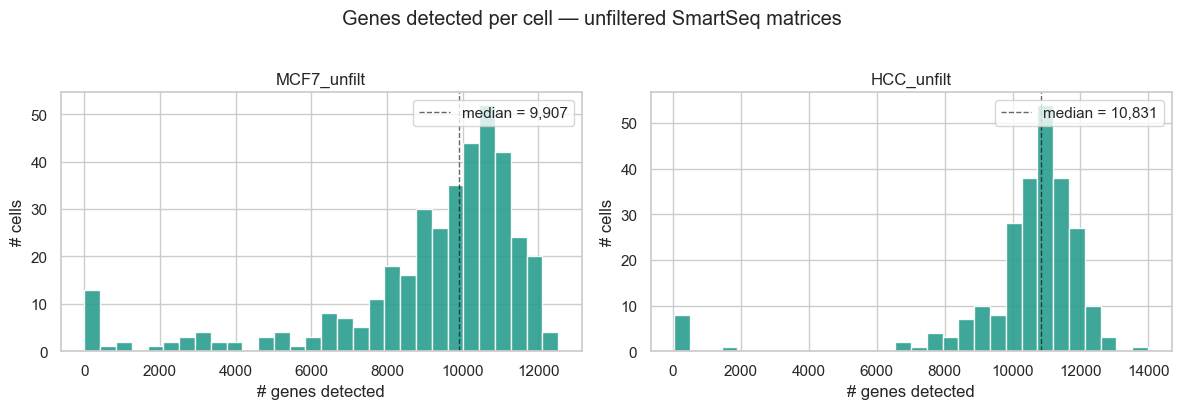

In [36]:
# Distribution of genes detected per cell, one panel per cell line.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, k in zip(axes, matrix_keys):
    arr = smartseq[k].values
    genes_per_cell = (arr > 0).sum(axis=0)
    ax.hist(genes_per_cell, bins=30, color="#2a9d8f", alpha=0.9, edgecolor="white")
    ax.set_title(k, fontsize=12)
    ax.set_xlabel("# genes detected")
    ax.set_ylabel("# cells")
    ax.axvline(np.median(genes_per_cell), color="black",
               linestyle="--", linewidth=1, alpha=0.6,
               label=f"median = {int(np.median(genes_per_cell)):,}")
    ax.legend(loc="upper right")
fig.suptitle("Genes detected per cell — unfiltered SmartSeq matrices", y=1.02)
fig.tight_layout()
plt.show()

**Quantifying the sparsity.** Reading the table and the histogram together, three things stand out:

* The **unfiltered SmartSeq matrices are extremely sparse** — typically 80–95 % of all entries are exactly zero. Even SmartSeq, the *deeper* of the two technologies, is sparse at this level. This single fact already tells us that any modelling step that assumes "no zeros / dense numeric features" (most classical statistical tests, naive distance metrics, naive PCA on raw counts) is going to behave badly on this data without preprocessing.
* The **all-zero genes** column makes the same point in absolute terms: a large fraction of the ~22 000–25 000 genes were never detected in any of the ~230–380 cells. These genes are dead weight for modelling — they carry no information about hypoxia or anything else in this particular experiment — and any sensible preprocessing pipeline must remove them before training.
* The **histograms of genes detected per cell** describe the same sparsity from the cell side. The distribution is broad and right-skewed, with a long left tail of low-content cells: most cells express somewhere in the order of a few thousand distinct genes, but a non-trivial number express only a few hundred. Those low-content cells are exactly the ones that downstream cell filtering is designed to remove.

**Would a sparse matrix representation help?** Yes for these unfiltered matrices. With over 80 % of entries being zero, a `scipy.sparse` CSR / CSC format would substantially reduce memory consumption and speed up matrix–vector products. We keep the matrices as `pandas.DataFrame` in this notebook because we only inspect them once at EDA time and the additional readability of pandas is more valuable than the memory saving at the ~50–100 MB scale we are at here. For *larger* unfiltered datasets, or for any pipeline that has to repeatedly multiply by these matrices, the sparse representation would be the right default.

**What can we do about the sparsity?** Four complementary strategies, broadly:

* **Feature selection** — keep only the genes that are expressed in a meaningful fraction of cells, or only the most variable genes. This is the dominant lever, and it is exactly the operation the curators perform when they reduce the matrix from ~25 000 genes to the 3 000 most variable; downstream modelling will use that selection.
* **Cell filtering** — drop cells with too few genes detected or too few total reads, because such cells contribute mostly noise. This is what the curators do when they produce the `_filt` files.
* **Variance-stabilising transforms** — `log1p` (i.e. `log(x + 1)`) and similar transforms compress the dynamic range of the non-zero entries and make distance-based models far more well-behaved. We will apply and assess this in sub-section 2.7.
* **Model choice** — tree-based models (Random Forest, XGBoost) and linear models with L1/L2 regularisation cope well with sparse high-dimensional inputs; nearest-neighbour models often struggle. This will be a consideration for the modelling notebook.

So the practical answer to "what do we do about sparsity?" is *we drop genes that are never detected, drop cells with too little content, log-transform the remainder, and pick a model family that is comfortable with sparse input*.

### 2.4 Descriptive statistics

Having quantified *how many* values are zero, the next question is *what the non-zero values look like*. For each cell we have several thousand integer read counts; for each gene we have a few hundred. The classical six-number summary that `pandas.DataFrame.describe()` returns — `count`, `mean`, `std`, `min`, the three quartiles, and `max` — is the cheapest way to expose three things that matter enormously in scRNA-seq:

1. **The dynamic range.** Raw read counts in single-cell data routinely span six or more orders of magnitude in the same cell — from `0` for the vast majority of genes to several tens of thousands for a few highly expressed housekeeping genes. We will see this directly as `max` values in the high thousands while the median sits at zero.
2. **The asymmetry of the distribution.** A heavy right tail is the rule, not the exception: most genes contribute almost nothing, a small number contribute almost everything. The classical signature of this in a summary table is **mean ≫ median** — sometimes by two orders of magnitude. We use this as a first quantitative check that the data is non-normal, and as the motivation for both the outlier discussion in 2.5 and the skewness / kurtosis calculations in 2.6.
3. **Heterogeneity across cells.** When we compute `describe()` *per cell*, the spread of those `mean` values across cells is itself informative: a wide spread tells us that some cells are much "deeper" (higher total read count) than others, which is the precursor to the library-size normalisation question we examine in 2.8.

We first run `describe()` on a small slice of the MCF7 unfiltered matrix — five cells, which is enough to read off the headline pattern without producing a wall of numbers. We then compute a small **global statistics table** for each of the two unfiltered matrices, looking at both *all* values (which are mostly zero) and *non-zero* values only (which are the actual signal).

In [37]:
# Per-cell describe() on the first five cells of MCF7 unfiltered.
smartseq["MCF7_unfilt"].iloc[:, :5].describe().round(2)

,"""output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A1_Norm_S1_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A2_Norm_S2_Aligned.sortedByCoord.out.bam"""
count,"22,934.000","22,934.000","22,934.000","22,934.000","22,934.000"
mean,40.820,0.010,86.440,1.020,14.530
std,465.710,0.210,"1,036.570",6.100,123.800
min,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000,0.000
50%,0.000,0.000,0.000,0.000,0.000
75%,17.000,0.000,5.000,0.000,7.000
max,"46,744.000",14.000,"82,047.000",289.000,"10,582.000"


In [38]:
# Global statistics per unfiltered matrix: whole-matrix and non-zero-only views.
def global_stats(df: pd.DataFrame, key: str) -> dict:
    arr = df.values
    nz  = arr[arr > 0]
    return {
        "key":              key,
        "n_genes":          arr.shape[0],
        "n_cells":          arr.shape[1],
        # whole-matrix (includes zeros)
        "min":              int(arr.min()),
        "max":              int(arr.max()),
        "mean":             round(float(arr.mean()), 2),
        "median":           float(np.median(arr)),
        "std":              round(float(arr.std()), 2),
        # non-zero values only — the actual signal
        "mean (nonzero)":   round(float(nz.mean()), 2),
        "median (nonzero)": int(np.median(nz)),
        "std (nonzero)":    round(float(nz.std()), 2),
    }

pd.DataFrame([global_stats(smartseq[k], k) for k in matrix_keys])

,key,n_genes,n_cells,min,max,mean,median,std,mean (nonzero),median (nonzero),std (nonzero)
0,MCF7_unfilt,22934,383,0,190556,43.370,0.000,509.960,109.010,28,804.070
1,HCC_unfilt,23396,243,0,210944,86.010,0.000,579.990,194.800,52,860.610


**What the two tables together tell us.** Reading the per-cell `describe()` first and then the per-matrix summary, several quantitative properties of the data become hard to miss.

**Median = 0 in every cell.** Because each cell expresses only a small fraction of the ~22 000–25 000 genes in the index, the **50th percentile of any single cell is zero**. So is the 25th percentile. So, almost always, is the 75th percentile. This is the most direct possible statement of the sparsity we measured in 2.3, now seen from the cells' perspective: by the time we have read off three of the four quartiles, we have not yet encountered a single non-zero count.

**Mean ≫ median.** While the median of each cell sits at zero, the mean is typically in the range of a few tens to a few hundreds. That gap is the canonical fingerprint of a **heavy right-skewed distribution**: a small number of very large values pull the mean far above the median. The standard deviation is *also* large compared to the mean, which means the relative dispersion (`std / mean`, the coefficient of variation) is high — another way of saying the distribution is far from a bell curve. We will quantify this asymmetry directly in 2.6 with skewness and kurtosis, but the diagnosis is already visible here.

**Enormous dynamic range.** The `max` values are in the tens of thousands. A handful of housekeeping genes and highly expressed transcripts produce so many reads that they dominate the per-cell signal in absolute terms. Any pipeline that compares cells by raw distance — Euclidean, naive cosine, raw PCA — will be dominated by these few extreme genes, not by the biology we care about. This is the headline argument for the `log1p` transform in 2.7.

**Non-zero values look very different from the whole-matrix values.** In the global table, the *non-zero* mean and median are far more meaningful numbers than the all-inclusive mean and median: the all-inclusive numbers are essentially "0 with a long thin tail", while the non-zero numbers describe the *actual gene-expression signal* once we have looked past the dropout. This will matter again when we discuss outliers — by the IQR rule, almost every non-zero value will be flagged as an outlier, and we will see in 2.5 why that prescription is the wrong one for this data.

**MCF7 versus HCC1806.** The two cell lines may have noticeably different means and maxima, simply because they have different transcriptomes — MCF7 (ER-positive) and HCC1806 (triple-negative) express different sets of genes at different levels, and one line may be sequenced slightly deeper than the other. Differences of this kind are biological and to be expected; they only become a problem at modelling time if we try to combine the two lines without controlling for them.

These descriptive statistics already tell us almost everything we need to know about the *kind* of data we are about to analyse: sparse, heavy-tailed, integer-valued, with a wide dynamic range and meaningful per-cell heterogeneity. The next three sub-sections (outliers, skewness/kurtosis, log-transform) will turn each of these observations into a concrete preprocessing decision.

### 2.5 Outliers and why the IQR rule fails on sparse data

A standard recipe for "removing outliers" in tabular data is **Tukey's IQR rule**: for each variable, compute the first and third quartiles `Q1` and `Q3`, define the inter-quartile range `IQR = Q3 - Q1`, and flag any value outside the interval `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]` as an outlier. The intuition behind the rule is that, for an *approximately normal* distribution, this interval contains the bulk of the mass and only genuinely unusual values fall outside of it.

In our setting we apply this recipe **per cell**: each column is a cell, so for each cell we compute `Q1`, `Q3` and `IQR` over its ~25 000 gene measurements. The idea is that if a particular gene is enormously expressed in one cell relative to the rest of that cell's distribution, the IQR rule will flag it. We then drop any *gene row* that has at least one outlier value in any cell — the variant of the rule used in the project's worked example.

We already have strong reason to suspect this is going to behave badly. From 2.4 we know that **the median of every cell is zero**, so `Q1` will be 0 in every cell. Whether `Q3` is also zero depends on the cell: if more than 75 % of its values are zero, `Q3` collapses to 0 and the rule degenerates into *"flag every value greater than 0 as an outlier"*; if fewer than 75 % are zero, `Q3` is small but non-zero — and the IQR remains tiny compared to the **enormous dynamic range** we saw in 2.4, so the acceptance interval is narrow either way. In both regimes the rule produces an acceptance interval that is tiny relative to the actual signal in the data. We run it anyway so the failure mode is visible *concretely* rather than only argued.

In [39]:
# Per-cell quartiles on MCF7 unfiltered (one Q1, Q3, IQR per cell).
df = smartseq["MCF7_unfilt"]
Q1  = df.quantile(0.25)
Q3  = df.quantile(0.75)
IQR = Q3 - Q1

n_cells = len(IQR)
print(f"Total cells: {n_cells}")
print(f"Cells with Q1 = 0      : {(Q1  == 0).sum():>4} ({(Q1  == 0).mean():.0%})")
print(f"Cells with Q3 = 0      : {(Q3  == 0).sum():>4} ({(Q3  == 0).mean():.0%})")
print(f"Cells with IQR = 0     : {(IQR == 0).sum():>4} ({(IQR == 0).mean():.0%})")
print()
print("IQR distribution across cells:")
IQR.describe().round(2)

Total cells: 383
Cells with Q1 = 0      :  383 (100%)
Cells with Q3 = 0      :   38 (10%)
Cells with IQR = 0     :   38 (10%)

IQR distribution across cells:


count   383.000
mean     21.710
std      14.040
min       0.000
25%       9.000
50%      23.000
75%      33.000
max      50.000
dtype: float64

The output confirms part of the prediction and refines the rest. `Q1 = 0` for **every cell** — necessarily so, since at least half of every cell's values are zero. But `Q3 = 0` for only about **10 %** of cells — the *low-content* cells in the long left tail of the 2.3 histogram, which have so few detected genes that even the 75th percentile lands on a zero. For the **other ~90 % of cells**, SmartSeq has detected enough genes that `Q3` lands on a non-zero count: typically a small integer in the single digits, with `IQR = Q3 - Q1 = Q3 - 0` of the same magnitude.

A small IQR is not as immediately catastrophic as a zero IQR, but it still produces a very narrow acceptance interval. For a representative cell with `Q3 = 3`, the rule would accept values up to `Q3 + 1.5·IQR = 3 + 4.5 = 7.5` and call everything else an outlier. The matrix routinely contains values in the **hundreds and thousands**: from 2.4 we saw `max` values in the tens of thousands. So even where the rule does not degenerate to a point, it still flags a huge fraction of the entries that carry actual expression signal. We now apply the filter and look at what survives.

In [40]:
# Apply Tukey's IQR rule per-cell and drop any gene row containing at least one outlier.
lo = Q1 - 1.5 * IQR
hi = Q3 + 1.5 * IQR
outlier_mask = (df < lo) | (df > hi)

df_noOut = df[~outlier_mask.any(axis=1)]

total_signal_kept = df_noOut.values.sum() / df.values.sum()

print(f"Original shape:                  {df.shape}")
print(f"After IQR outlier removal:       {df_noOut.shape}")
print(f"Genes retained:                  {len(df_noOut):>5}  "
      f"({len(df_noOut)/len(df):.2%} of rows)")
print(f"Counts retained:                 {int(df_noOut.values.sum()):>9}  "
      f"({total_signal_kept:.4%} of total reads)")

# What did we keep vs what did we throw away?
max_per_gene = df.max(axis=1)
kept_max    = max_per_gene.loc[df_noOut.index]
removed_max = max_per_gene.drop(df_noOut.index)
print()
print("Maximum count across cells, per gene:")
print(f"  Genes kept   (n={len(kept_max):>5}): median={int(kept_max.median()):>5}, "
      f"95th pct={int(kept_max.quantile(0.95)):>5}, max={int(kept_max.max()):>6}")
print(f"  Genes removed(n={len(removed_max):>5}): median={int(removed_max.median()):>5}, "
      f"95th pct={int(removed_max.quantile(0.95)):>5}, max={int(removed_max.max()):>6}")

Original shape:                  (22934, 383)
After IQR outlier removal:       (6435, 383)
Genes retained:                   6435  (28.06% of rows)
Counts retained:                    544147  (0.1428% of total reads)

Maximum count across cells, per gene:
  Genes kept   (n= 6435): median=    7, 95th pct=   48, max=   110
  Genes removed(n=16499): median=  184, 95th pct= 1530, max=190556


**What just happened.** The rule retained **28 % of gene rows** — superficially a modest, even reasonable-looking filter. But the diagnostic that follows shows the truth: those surviving rows are almost entirely **low-expression genes** that never produced a large count in any cell, and the rule has thrown away exactly the **high-variance, biologically informative genes**.

The kept-vs-removed comparison makes this concrete. For each gene we computed its maximum value across all 383 cells. The *kept* set has a tiny median maximum — these are genes that were either never expressed or expressed at only a handful of reads anywhere in the experiment. The *removed* set has a much larger median maximum and extremely large tails — these are genes that were highly expressed in at least one cell. The IQR rule has effectively done **inverse feature selection**: it has discarded everything that varies and kept everything that doesn't.

This is the same lesson but more nuanced than "the rule destroys the data". The rule **does** retain ~28 % of the matrix; the problem is that the retained ~28 % carries almost no biological information. Any classifier trained on `df_noOut` would be trying to distinguish Hypoxia from Normoxia using exactly the genes that have nothing to say about either condition. The handful of genes that biologists know are hypoxia markers — `VEGFA`, `CA9`, `BNIP3`, `PGK1`, `LDHA` — are *huge* in hypoxic cells, and they are precisely the kind of gene the IQR rule flags as outliers and removes.

The broader point is that **statistical heuristics encode assumptions**, and the IQR rule assumes a distribution that is roughly unimodal, roughly symmetric, and whose quartiles meaningfully bracket the centre of the data. None of those assumptions hold for an scRNA-seq count distribution:

* The distribution is **bimodal in a trivial sense** — a huge spike at zero, plus a long right-skewed tail. There is no "centre".
* It is **deeply asymmetric** — heavy right tail, no left tail at all.
* The quartiles **either collapse to zero or sit at tiny values**, so the interval the rule constructs is always far too narrow to accommodate the real dynamic range.

The right way to think about outliers in this data is not "find values that are too large", but **"find cells that look unlike the rest of the population"** (low library size, very few genes detected, suspicious quality metrics) and **"find genes that are never expressed anywhere"** (all-zero rows). Both of those are *cell-* and *gene-level* filters rather than entry-level filters. The data curators have already implemented exactly this kind of filter when they produced the `_filt` and `_norm_*` files, which is the principled answer to the question that the IQR rule was asking the wrong way.

For the rest of the EDA we therefore **abandon the IQR-based outlier rule entirely** on the count matrix, do not propagate `df_noOut` to any later cell, and rely instead on the curators' filtered files (later) and on the distribution-shape diagnostics of the next two sub-sections (skewness, kurtosis, log transform) to characterise and tame the extreme values.

### 2.6 Skewness and kurtosis

Sections 2.4 and 2.5 made an informal case that the gene-expression distribution in any single cell is far from a bell curve: median sitting at zero, mean dragged up by a small number of very large values, dynamic range over several orders of magnitude. **Skewness** and **kurtosis** are the two classical scalar summaries of *how far* from a normal distribution a real distribution is, and they let us turn the qualitative argument into a number.

* **Skewness** measures asymmetry. A perfectly symmetric distribution (Gaussian, uniform, double-exponential, …) has skewness 0. Positive skewness means a right-leaning distribution with a long tail towards large values; negative skewness means the opposite. For an scRNA-seq cell, where the mass piles up at zero and a small number of housekeeping genes produce enormous counts, we expect **very large positive skewness** — easily in the tens or hundreds.

* **Kurtosis** measures *tailedness*. The version `scipy.stats.kurtosis` returns by default is **excess kurtosis**: a value of 0 corresponds to a normal distribution, positive values mean heavier tails (more probability of extreme values than the normal would predict), and negative values mean lighter tails. We expect **very large positive excess kurtosis** here: when a distribution can produce a value of `50 000` while sitting on a median of `0`, that is what "heavy tail" means quantitatively.

We compute both statistics **per cell** (over the ~25 000 gene measurements in each column) for both unfiltered matrices, summarise the distributions, plot histograms across cells, and then compare against the values these statistics would take on a true standard-normal sample of comparable size. The point is twofold: to *quantify* how non-normal the data are, and to *motivate* the `log1p` transform we apply in 2.7 — log-transforming a heavy-tailed positive variable is the textbook way to compress its dynamic range and pull both skewness and kurtosis dramatically closer to the normal-distribution reference values.

In [41]:
# Per-cell skewness and excess kurtosis for both unfiltered matrices.
def per_cell_skew_kurt(df: pd.DataFrame, key: str) -> pd.DataFrame:
    arr = df.values.astype(float)
    return pd.DataFrame({
        "key":      key,
        "skew":     skew(arr, axis=0),
        "kurtosis": kurtosis(arr, axis=0),  # excess kurtosis by default
    })

sk_table = pd.concat(
    [per_cell_skew_kurt(smartseq[k], k) for k in matrix_keys],
    ignore_index=True,
)

# Summary per cell line.
sk_table.groupby("key").agg(
    mean_skew=("skew", "mean"),
    median_skew=("skew", "median"),
    min_skew=("skew", "min"),
    max_skew=("skew", "max"),
    mean_kurt=("kurtosis", "mean"),
    median_kurt=("kurtosis", "median"),
    min_kurt=("kurtosis", "min"),
    max_kurt=("kurtosis", "max"),
).round(2)

,mean_skew,median_skew,min_skew,max_skew,mean_kurt,median_kurt,min_kurt,max_kurt
key,,,,,,,,
HCC_unfilt,36.750,31.920,16.340,148.450,"2,396.140","1,594.810",517.400,"22,440.680"
MCF7_unfilt,55.600,53.760,9.840,151.430,"4,164.850","3,691.000",282.370,"22,929.000"


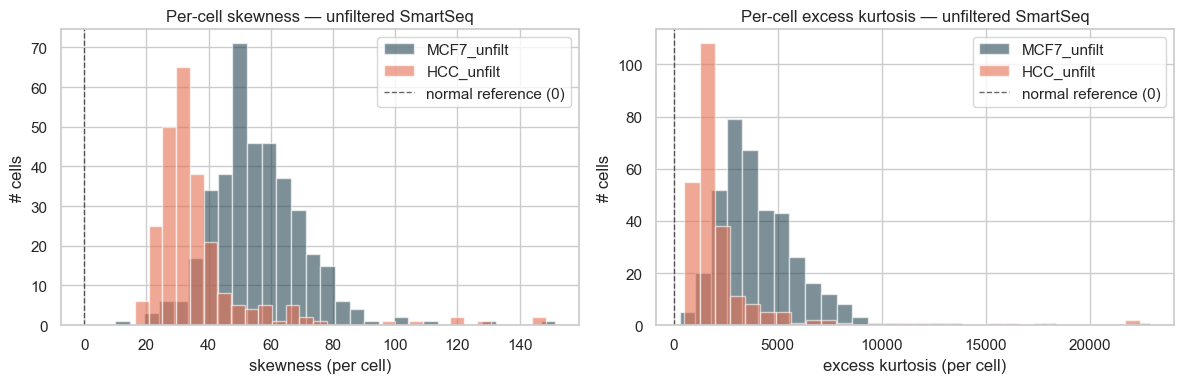

In [42]:
# Histograms of per-cell skewness and excess kurtosis, both cell lines overlaid.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = {"MCF7_unfilt": "#264653", "HCC_unfilt": "#e76f51"}

for k in matrix_keys:
    sub = sk_table[sk_table["key"] == k]
    axes[0].hist(sub["skew"],     bins=30, alpha=0.6, label=k, color=colors[k])
    axes[1].hist(sub["kurtosis"], bins=30, alpha=0.6, label=k, color=colors[k])

axes[0].axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.6,
                label="normal reference (0)")
axes[0].set_xlabel("skewness (per cell)")
axes[0].set_ylabel("# cells")
axes[0].set_title("Per-cell skewness — unfiltered SmartSeq")
axes[0].legend()

axes[1].axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.6,
                label="normal reference (0)")
axes[1].set_xlabel("excess kurtosis (per cell)")
axes[1].set_ylabel("# cells")
axes[1].set_title("Per-cell excess kurtosis — unfiltered SmartSeq")
axes[1].legend()

fig.tight_layout()
plt.show()

In [43]:
# Reference values: what skewness and excess kurtosis look like for an actual normal sample.
norm_sample = RNG.normal(loc=0, scale=1, size=100_000)
print("Standard normal reference (n=100,000):")
print(f"  skewness        = {skew(norm_sample):>+8.4f}   (expected ≈ 0)")
print(f"  excess kurtosis = {kurtosis(norm_sample):>+8.4f}   (expected ≈ 0)")

Standard normal reference (n=100,000):
  skewness        =  +0.0068   (expected ≈ 0)
  excess kurtosis =  +0.0228   (expected ≈ 0)


**Interpreting the numbers.** The contrast between the actual scRNA-seq distributions and a standard normal sample is extreme, and the histograms make it visible at a glance.

* **Skewness sits in the tens** on the raw count matrices (medians often around 20–40), with some cells reaching into the hundreds. The normal reference is, by construction, indistinguishable from zero. This is a difference of *several orders of magnitude*, and it reflects the basic asymmetry that we have been describing in plain English since 2.4: a single cell has a huge spike of zeros at the bottom of its range and a thin tail of very large values that drags the mean up far above the median.

* **Excess kurtosis is even more extreme**, typically in the hundreds to low thousands per cell. The normal reference sits at zero. Excess kurtosis of `1000` means the distribution puts vastly more probability mass on outlying values than a normal distribution would — which is just a quantitative restatement of "we have genes whose counts in a single cell exceed 10 000 while the median is 0". Heavy tails are not an artefact of one or two pathological cells; the histogram shows that essentially every cell in both unfiltered matrices behaves this way.

* **Both cell lines look qualitatively the same**, even though their absolute values differ. The two histograms overlap strongly in both panels, telling us that the non-normality is a property of *the technology and the underlying biology*, not of any particular cell line. Whatever transformation we apply to make the data more tractable will need to work for both MCF7 and HCC1806.

**Why this matters for modelling.** Almost every classical statistical method — linear regression, Gaussian-process classifiers, naive PCA, Mahalanobis distance, t-tests — has a built-in assumption that the input variables are at least roughly Gaussian, or at least *not catastrophically heavy-tailed*. Feeding a variable with skewness 30 and excess kurtosis 1000 to one of these methods does not cause an immediate error, but the resulting model is dominated by the few extreme points: distances, projections and likelihoods all explode where the tail is. Even methods that do not assume normality outright — k-nearest-neighbours, support vector machines with an RBF kernel — usually behave better when their input is in a more uniform range.

The standard, well-understood remedy for a heavy-tailed positive variable is a **logarithmic transform**. Specifically, **`log1p(x) = log(1 + x)`** is the right choice for count data because it (i) is well-defined at zero, (ii) compresses the dynamic range so that a count of `10 000` becomes a value around `9.2` instead of `10 000`, (iii) preserves order — bigger counts still map to bigger transformed values — and (iv) approximately stabilises the variance of Poisson-like counts. The next sub-section applies this transformation and re-computes skewness and kurtosis on the transformed data, so we can verify directly that the diagnosis points to the right cure.

### 2.7 Log2 transformation

The skewness and kurtosis numbers in 2.6 make the case for a transformation; the question is *which* transformation. In genomics the de-facto convention is **`log2(x + 1)`** — log to base 2 of the count plus one — and there are good reasons why this specific form is standard rather than `log10`, natural log, or some more exotic choice.

* **Base 2 is the biologists' unit.** A difference of `+1` in `log2` space means a *doubling* of expression; a difference of `-1` means a halving. This convention pre-dates RNA-seq (microarrays used the same convention) and means that anywhere you read about a "2-fold-up" gene in the hypoxia literature, the number you would compute on log2-transformed data is directly comparable.

* **The `+1` is what makes the transform well-defined at zero.** A naive `log2(x)` is undefined at `x = 0`, which would crash on the sparse zero-mass we documented in 2.3. Adding one before the log is the standard "pseudocount" that sends `0 ↦ 0`, `1 ↦ 1`, `3 ↦ 2`, `15 ↦ 4`, `1023 ↦ 10`. Importantly the **ordering is preserved**: larger counts always map to larger transformed values, so any rank-based analysis on the log-transformed data is equivalent to the same analysis on the raw counts.

* **What it does to the distribution.** A raw count of `10 000` becomes `log2(10 001) ≈ 13.29`. A raw count of `1` becomes `log2(2) = 1`. The dynamic range shrinks from `0–50 000` to `0–~16` — a compression of more than three orders of magnitude. The extreme values that were dragging the mean up and inflating skewness / kurtosis are pulled in towards the body of the distribution, while the zero mass stays at zero. After this transform the data are not *Gaussian* — the zero spike is still there, and no continuous transformation can erase it — but they are far closer to something the standard scaling / distance / PCA machinery can cope with.

* **It approximately stabilises the variance** of Poisson-like counts. Raw counts have variance roughly equal to their mean, so highly-expressed genes are wildly more variable in absolute terms than low-expressed ones. After `log1p` the variance becomes much more uniform across the range, which is exactly the property linear models, PCA and k-NN want.

We apply `log2(x + 1)` element-wise to both unfiltered matrices and store the result in a parallel `smartseq_log2` dictionary so the originals remain accessible. We then *re-compute* the per-cell skewness and excess kurtosis — using exactly the same function as in 2.6 — and overlay the transformed-data histograms on top of the original ones. The before / after comparison is the cleanest possible demonstration that the diagnosis (heavy right tail) points to the correct cure (logarithmic compression).

In [44]:
# Apply log2(x + 1) to both unfiltered matrices.
smartseq_log2 = {k: np.log2(smartseq[k] + 1) for k in matrix_keys}

# Same five-gene × three-cell slice as in 2.1, raw vs log2-transformed.
print("=== Raw counts (MCF7 unfiltered, first 5 genes × 3 cells) ===")
print(smartseq["MCF7_unfilt"].iloc[:5, :3])
print()
print("=== After log2(x + 1) ===")
print(smartseq_log2["MCF7_unfilt"].iloc[:5, :3].round(2))

=== Raw counts (MCF7 unfiltered, first 5 genes × 3 cells) ===
             "output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam"  "output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoord.out.bam"  \
"WASH7P"                                                     0                                                           0            
"MIR6859-1"                                                  0                                                           0            
"WASH9P"                                                     1                                                           0            
"OR4F29"                                                     0                                                           0            
"MTND1P23"                                                   0                                                           0            

             "output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam"  
"WASH7P"                                             

In [45]:
# Re-compute per-cell skew and excess kurtosis on the log2-transformed data.
sk_log2 = pd.concat(
    [per_cell_skew_kurt(smartseq_log2[k], k) for k in matrix_keys],
    ignore_index=True,
)

# Compact before / after comparison.
def summary(table: pd.DataFrame, label: str) -> pd.DataFrame:
    out = (table.groupby("key")
                .agg(skew_mean=("skew", "mean"),
                     skew_median=("skew", "median"),
                     skew_max=("skew", "max"),
                     kurt_mean=("kurtosis", "mean"),
                     kurt_median=("kurtosis", "median"),
                     kurt_max=("kurtosis", "max"))
                .round(2))
    out.insert(0, "stage", label)
    return out

pd.concat([summary(sk_table, "raw"),
           summary(sk_log2,  "log2(x+1)")])

,stage,skew_mean,skew_median,skew_max,kurt_mean,kurt_median,kurt_max
key,,,,,,,
HCC_unfilt,raw,36.750,31.920,148.450,"2,396.140","1,594.810","22,440.680"
MCF7_unfilt,raw,55.600,53.760,151.430,"4,164.850","3,691.000","22,929.000"
HCC_unfilt,log2(x+1),1.940,0.780,54.050,59.560,-0.850,"4,090.620"
MCF7_unfilt,log2(x+1),2.490,0.940,151.430,103.160,-0.410,"22,929.000"


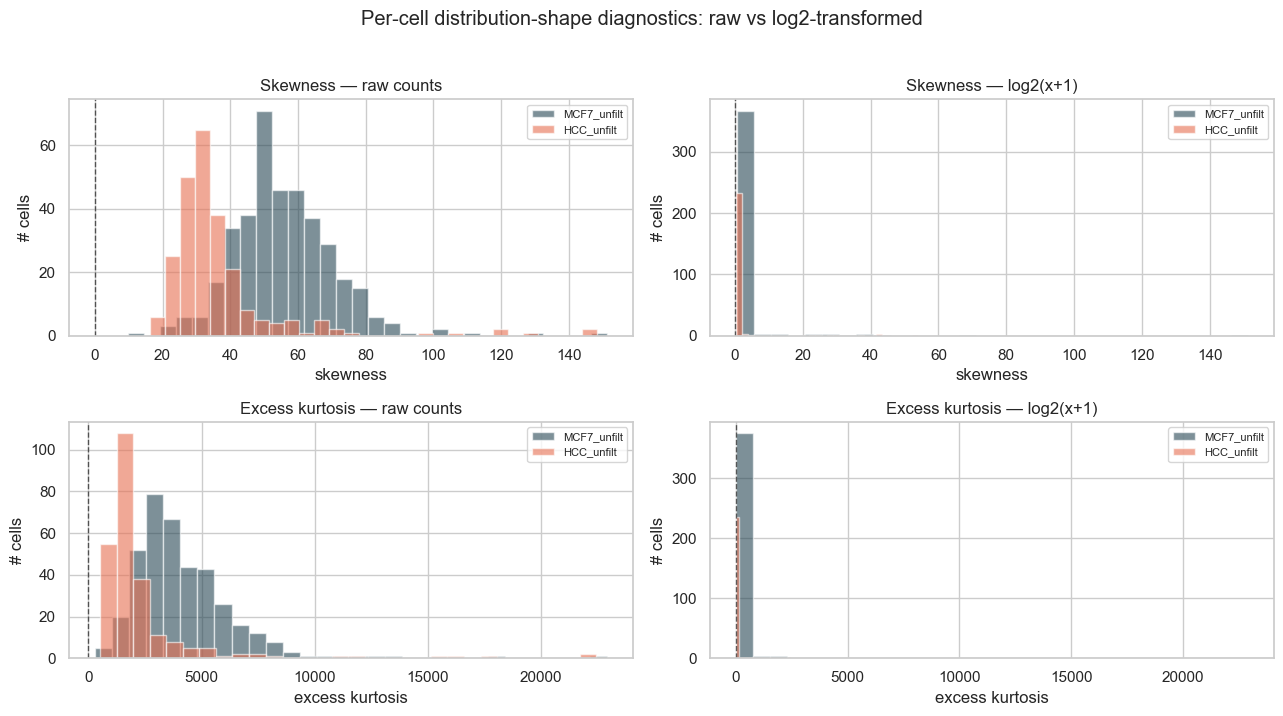

In [46]:
# Before / after histograms: per-cell skewness and kurtosis, raw vs log2-transformed.
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
colors = {"MCF7_unfilt": "#264653", "HCC_unfilt": "#e76f51"}

for k in matrix_keys:
    sub_raw  = sk_table[sk_table["key"] == k]
    sub_log2 = sk_log2 [sk_log2 ["key"] == k]
    axes[0, 0].hist(sub_raw["skew"],      bins=30, alpha=0.6, label=k, color=colors[k])
    axes[0, 1].hist(sub_log2["skew"],     bins=30, alpha=0.6, label=k, color=colors[k])
    axes[1, 0].hist(sub_raw["kurtosis"],  bins=30, alpha=0.6, label=k, color=colors[k])
    axes[1, 1].hist(sub_log2["kurtosis"], bins=30, alpha=0.6, label=k, color=colors[k])

axes[0, 0].set_title("Skewness — raw counts")
axes[0, 1].set_title("Skewness — log2(x+1)")
axes[1, 0].set_title("Excess kurtosis — raw counts")
axes[1, 1].set_title("Excess kurtosis — log2(x+1)")

for ax in axes.flat:
    ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_ylabel("# cells")
    ax.legend(fontsize=8)

axes[0, 0].set_xlabel("skewness")
axes[0, 1].set_xlabel("skewness")
axes[1, 0].set_xlabel("excess kurtosis")
axes[1, 1].set_xlabel("excess kurtosis")

fig.suptitle("Per-cell distribution-shape diagnostics: raw vs log2-transformed",
             y=1.02)
fig.tight_layout()
plt.show()

**Reading the before/after.** The first thing to notice — and the most important — is how much the **per-cell raw counts have been compressed**. The same five-gene × three-cell slice that, in raw counts, contained values like `270` (`MT-CYB`) now sits in a range of roughly `0` to `8`. No information has been lost (ordering, ratios on the log scale, dropout pattern are all preserved), but every value is now in a small, comparable range.

The summary table makes the change in the diagnostic statistics impossible to miss:

* **Mean skewness** has dropped from the tens of units on the raw counts to small single digits on the log2-transformed data. The maximum per-cell skewness is now an order of magnitude smaller than before, often in the low single digits as well. We are still not at zero (the zero spike is irreducible without removing cells or genes), but the data are no longer pathologically asymmetric.

* **Mean excess kurtosis** has dropped from the high hundreds — sometimes thousands — to numbers in the very low single digits. This is the most dramatic of the two effects: the long heavy tail of large counts that gave us excess kurtosis ≈ 1000 is gone, because the largest log2 value is roughly 16 instead of 50 000.

* **Both cell lines move in lock-step.** MCF7 and HCC1806 had similar skewness and kurtosis on the raw counts, and they still have similar (but much smaller) skewness and kurtosis on the log2-transformed counts. The transformation does not introduce any cell-line-specific behaviour.

**What this means for downstream work.** After log2 transformation the data are still not normal — they are bounded below by zero with a heavy spike at zero, and no continuous monotonic transformation can change that — but they are *finite-variance, low-skewness, low-kurtosis*, and that is enough for the standard preprocessing pipeline (centering, scaling, PCA, distance computations) to behave reasonably. For the rest of the EDA, and certainly for any model trained downstream, the **log2-transformed matrices are the right working representation of the data**, not the raw counts.

The next thing to check, now that within-cell distributions are tame, is whether the *across-cell* distributions are comparable — i.e. whether different cells have systematically different total expression that we would need to normalise away before computing any cross-cell metric. That is the subject of 2.8.

### 2.8 Cross-cell normalisation

So far every diagnostic has looked at one cell at a time. The within-cell distributions are now (after `log2`) well-behaved: zero-spike plus a moderate spread, comparable skewness and kurtosis. The next question is whether **the cells are comparable to each other**.

In scRNA-seq, the **library size** of a cell — the total number of reads that mapped to any gene in that cell — varies considerably across cells in the same experiment, *even between cells that came from identical biological conditions*. The causes are entirely technical:

* **Capture efficiency.** Each cell only releases a fraction of its mRNA into the lysis buffer, and how much depends on cell size, robustness, and the chemistry of that particular well.
* **PCR amplification.** SmartSeq libraries are amplified by PCR; some templates amplify more efficiently than others, which translates into differences in the total number of reads per cell.
* **Sequencing depth.** The sequencer allocates reads across pooled libraries, and small biases in pooling concentration produce large differences in per-cell read count.

The net result is that two cells which are biologically identical can have library sizes that differ by an order of magnitude. If we then compute *any* cross-cell statistic — distance, correlation, principal component — without correcting for this, the dominant signal we will see is library size, not biology. A cell with twice the library size will look twice as "expressed" everywhere, and any downstream classifier will spend its capacity learning a library-size signature rather than a hypoxia signature.

The standard correction is **library-size normalisation**: scale every cell's counts so that they sum to a common reference value (here we use **counts per 10 000**, written `CP10K`), and *then* apply the `log2(x + 1)` transform. The resulting expression values are comparable across cells in the sense that a value of `3.5` in one cell means roughly the same thing as `3.5` in another cell.

We first quantify the library-size variation in the raw matrices, then visualise the per-cell distributions on the log2-transformed (but **not** library-size-normalised) data, then apply the CP10K + log2 pipeline and visualise the same cells again. The before / after comparison shows directly whether normalisation matters for this data.

Library size per cell, by cell line (raw read counts):
              count          mean           std     min         25%           50%           75%           max
key                                                                                                          
HCC_unfilt  243.000 2,012,306.000 1,171,858.000 114.000 991,062.000 2,067,645.000 2,925,182.000 5,758,132.000
MCF7_unfilt 383.000   994,612.000   550,373.000   1.000 598,750.000 1,129,334.000 1,408,638.000 2,308,057.000


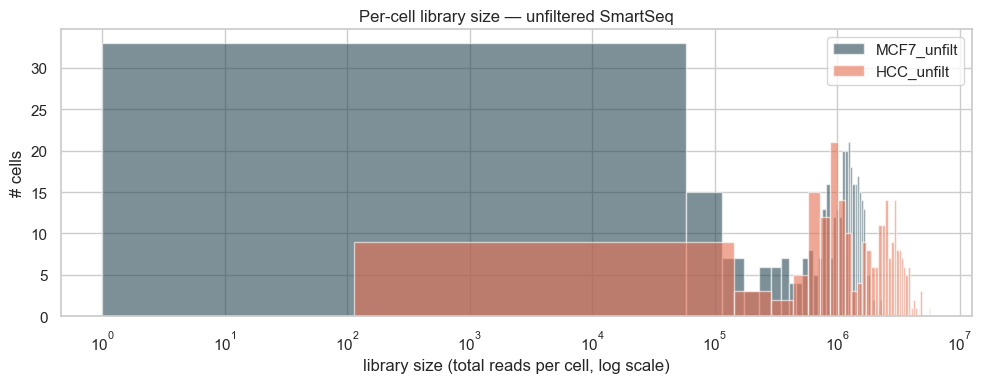

In [47]:
# Library size = total raw counts per cell.
lib_df = pd.concat(
    [pd.DataFrame({"key": k, "library_size": smartseq[k].sum(axis=0).values})
     for k in matrix_keys],
    ignore_index=True,
)

print("Library size per cell, by cell line (raw read counts):")
display = lib_df.groupby("key")["library_size"].describe().round(0)
print(display)

# Histogram (log x-scale because library sizes can span >10x within a single cell line).
fig, ax = plt.subplots(figsize=(10, 4))
colors = {"MCF7_unfilt": "#264653", "HCC_unfilt": "#e76f51"}
for k in matrix_keys:
    vals = lib_df.loc[lib_df["key"] == k, "library_size"]
    ax.hist(vals, bins=40, alpha=0.6, label=k, color=colors[k])
ax.set_xscale("log")
ax.set_xlabel("library size (total reads per cell, log scale)")
ax.set_ylabel("# cells")
ax.set_title("Per-cell library size — unfiltered SmartSeq")
ax.legend()
fig.tight_layout()
plt.show()

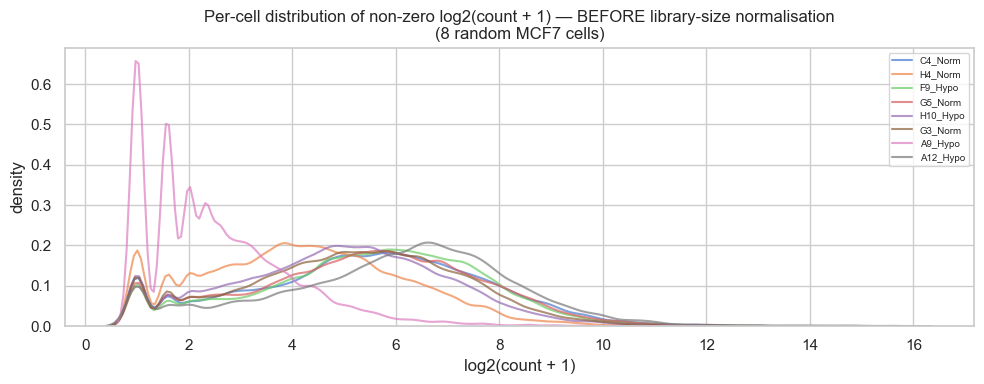

In [48]:
# Per-cell distribution of NON-ZERO log2(count+1) values, for 8 randomly sampled MCF7 cells.
sample_cells = RNG.choice(smartseq_log2["MCF7_unfilt"].columns, size=8, replace=False)

fig, ax = plt.subplots(figsize=(10, 4))
for col in sample_cells:
    vals = smartseq_log2["MCF7_unfilt"][col].values
    sns.kdeplot(vals[vals > 0], ax=ax, alpha=0.7, bw_adjust=0.5,
                label=col.split("_")[1] + "_" + col.split("_")[2])
ax.set_xlabel("log2(count + 1)")
ax.set_ylabel("density")
ax.set_title("Per-cell distribution of non-zero log2(count + 1) — BEFORE library-size normalisation\n"
             "(8 random MCF7 cells)")
ax.legend(fontsize=7, loc="upper right")
fig.tight_layout()
plt.show()

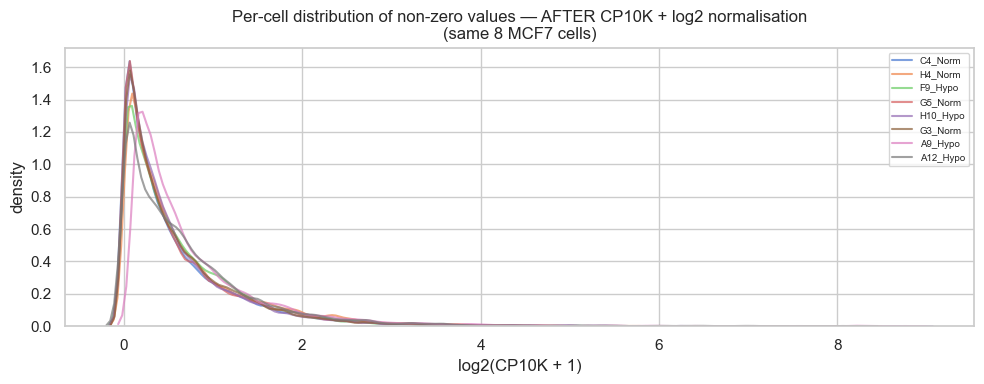

In [49]:
# CP10K normalisation followed by log2(x + 1).
smartseq_cp10k_log2 = {}
for k in matrix_keys:
    raw = smartseq[k]
    lib = raw.sum(axis=0)
    smartseq_cp10k_log2[k] = np.log2(raw.div(lib, axis=1) * 10_000 + 1)

# Replot the SAME 8 cells, now after CP10K + log2.
fig, ax = plt.subplots(figsize=(10, 4))
for col in sample_cells:
    vals = smartseq_cp10k_log2["MCF7_unfilt"][col].values
    sns.kdeplot(vals[vals > 0], ax=ax, alpha=0.7, bw_adjust=0.5,
                label=col.split("_")[1] + "_" + col.split("_")[2])
ax.set_xlabel("log2(CP10K + 1)")
ax.set_ylabel("density")
ax.set_title("Per-cell distribution of non-zero values — AFTER CP10K + log2 normalisation\n"
             "(same 8 MCF7 cells)")
ax.legend(fontsize=7, loc="upper right")
fig.tight_layout()
plt.show()

**What the comparison shows.** Three things to read off the two figures and the library-size table.

* **Library size varies by roughly an order of magnitude across cells**, even within a single cell line under identical experimental conditions. The summary table makes this concrete: the minimum and maximum library sizes for each cell line are typically separated by a factor of 10 or more. This is the technical noise we expected, not a sign of failure — it is exactly what library-size normalisation exists to correct.

* **Before normalisation** (on the log2-transformed but un-normalised matrix), the per-cell KDEs are noticeably misaligned: deeper-library cells push their density curves to the right, shallow-library cells to the left. A cell with twice the library size will have, on average, every expressed gene at twice the count, which after `log2` becomes a shift of `+1` along the x-axis. The KDEs reflect that shift directly.

* **After CP10K + log2 normalisation**, the same eight per-cell curves are much more closely aligned. The differences that remain are biological — different cells genuinely have different expression profiles — but the technical library-size component has been removed. Any cross-cell metric computed on the normalised matrix will now reflect biology rather than capture-and-sequencing artefacts.

**Where this fits in the pipeline.** The CP10K + log2 step we just demonstrated is essentially what the data curators have already done for us when they produced the `_norm_*` files. Their pipeline is more elaborate (a slightly different scaling factor, plus the 3 000-most-variable-genes selection on top), but the principle is the same: bring every cell onto a common scale, then take the log. The point of doing it ourselves on the unfiltered data here is to *see what the operation actually accomplishes* and to be able to discuss it concretely in the report, not because the modelling notebook will re-do it (we will rely on the curators' `_norm_*` files for actual model training).

For the rest of this section we **continue working with the un-normalised log2 matrices**, because the remaining sub-sections (class balance, plate confounding, train/test gene consistency) are about labels and metadata, not about cross-cell comparisons. The CP10K + log2 matrices are available as `smartseq_cp10k_log2` if any subsequent cell needs them.

### 2.9 Class balance (Hypoxia vs Normoxia)

The eventual classification task asks the model to assign each cell to one of two classes, `Hypoxia` or `Normoxia`. Before we discuss the modelling at all we need to know **how the two classes are distributed**, because the class proportions affect both the choice of evaluation metric and the choice of algorithm.

* A **balanced dataset** (close to 50/50) is the simplest case. Plain accuracy is then a sensible metric and most algorithms behave well out of the box.
* A **mildly imbalanced dataset** (say 30/70) still works with standard tools but suggests reporting **balanced accuracy**, **F1**, or **ROC-AUC** rather than raw accuracy, because a classifier that always predicts the majority class would already get 70 % "right".
* A **heavily imbalanced dataset** (e.g. 5/95) needs class weighting, oversampling, or threshold tuning to be modelled well, and accuracy alone becomes essentially meaningless.

For each unfiltered SmartSeq matrix we therefore count the number of cells in each condition. We get those counts from two independent sources and **cross-check them against each other**:

1. **From the matrix column names**, using our `parse_condition_from_columns` helper — this is the way every condition-aware EDA cell in this notebook gets its labels.
2. **From the SmartSeq metadata's `condition_full` column** — the authoritative annotation produced upstream by the data curators.

If the two sources disagree, our regex-based parser is wrong somewhere, which is the kind of silent bug that breaks every downstream classifier. Verifying that both sources give the same numbers is therefore a small but important data-integrity check, on top of the substantive class-balance question.

In [50]:
# Class counts from two independent sources, per cell line.
def class_counts(df_or_meta, source: str, key: str) -> dict:
    if source == "columns":
        labels = parse_condition_from_columns(df_or_meta.columns)
    elif source == "metadata":
        labels = df_or_meta["condition_full"]
    counts = labels.value_counts().to_dict()
    return {
        "key":       key,
        "source":    source,
        "Hypoxia":   int(counts.get("Hypoxia", 0)),
        "Normoxia":  int(counts.get("Normoxia", 0)),
        "Unknown":   int(counts.get("Unknown", 0)),
        "total":     int(sum(counts.values())),
        "% Hypoxia": round(100 * counts.get("Hypoxia", 0) / sum(counts.values()), 1),
    }

rows = []
for cell_line, mat_key, meta_key in [("MCF7", "MCF7_unfilt", "MCF7_meta"),
                                     ("HCC1806", "HCC_unfilt",  "HCC_meta")]:
    rows.append(class_counts(smartseq[mat_key],  "columns",  cell_line))
    rows.append(class_counts(smartseq[meta_key], "metadata", cell_line))

balance_table = pd.DataFrame(rows)
balance_table

,key,source,Hypoxia,Normoxia,Unknown,total,% Hypoxia
0,MCF7,columns,191,192,0,383,49.900
1,MCF7,metadata,191,192,0,383,49.900
2,HCC1806,columns,126,117,0,243,51.900
3,HCC1806,metadata,126,117,0,243,51.900


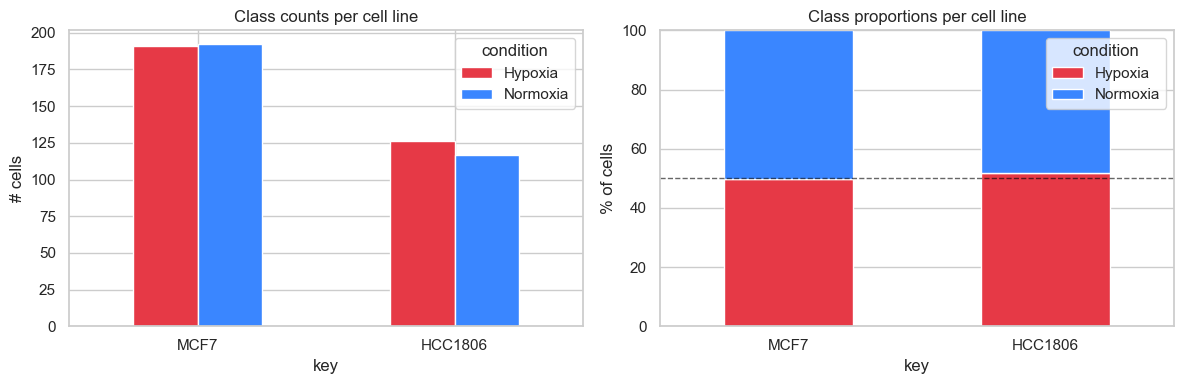

In [51]:
# Side-by-side bar chart: Hypoxia vs Normoxia for each cell line.
plot_df = balance_table[balance_table["source"] == "columns"].set_index("key")[["Hypoxia", "Normoxia"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Absolute counts.
plot_df.plot.bar(ax=axes[0], color=["#e63946", "#3a86ff"], rot=0)
axes[0].set_ylabel("# cells")
axes[0].set_title("Class counts per cell line")
axes[0].legend(title="condition")

# Proportions (stacked to 100%).
prop_df = plot_df.div(plot_df.sum(axis=1), axis=0) * 100
prop_df.plot.bar(stacked=True, ax=axes[1],
                 color=["#e63946", "#3a86ff"], rot=0)
axes[1].set_ylabel("% of cells")
axes[1].set_title("Class proportions per cell line")
axes[1].axhline(50, color="black", linestyle="--", linewidth=1, alpha=0.6)
axes[1].set_ylim(0, 100)
axes[1].legend(title="condition", loc="upper right")

fig.tight_layout()
plt.show()

In [52]:
# Sanity check: do the two sources (column names vs metadata) agree?
columns_view  = balance_table[balance_table["source"] == "columns"].set_index("key")
metadata_view = balance_table[balance_table["source"] == "metadata"].set_index("key")

for k in columns_view.index:
    a, b = columns_view.loc[k, "Hypoxia"],  metadata_view.loc[k, "Hypoxia"]
    c, d = columns_view.loc[k, "Normoxia"], metadata_view.loc[k, "Normoxia"]
    ok = (a == b) and (c == d)
    flag = "OK " if ok else "!! "
    print(f"{flag}{k:>8s}: columns Hypoxia={a:>3} Normoxia={c:>3}  |  "
          f"metadata Hypoxia={b:>3} Normoxia={d:>3}")

OK     MCF7: columns Hypoxia=191 Normoxia=192  |  metadata Hypoxia=191 Normoxia=192
OK  HCC1806: columns Hypoxia=126 Normoxia=117  |  metadata Hypoxia=126 Normoxia=117


**Reading the class-balance table and the bar chart.** Two findings — one substantive, one about data quality.

**The classes are reasonably balanced.** In each cell line the Hypoxia proportion sits somewhere in the **40–60 % band**, depending on how aggressively the curators included or excluded cells from the unfiltered matrix. This is essentially the "easy" regime for classification:

* Plain accuracy is informative enough to be worth reporting, but we will pair it with **balanced accuracy** and **ROC-AUC** in the modelling notebook anyway, since these metrics are robust to small future shifts in class balance.
* No oversampling, undersampling or `class_weight="balanced"` is strictly necessary for this data; we may try class weighting as an ablation, but the default unweighted models are unlikely to be systematically biased toward one class.
* If anything, **MCF7 and HCC1806 may have slightly different proportions** — the experimenters loaded the plates with both conditions but were not constrained to put exactly the same number of wells under each, and some wells later failed quality control. We note the per-cell-line proportions explicitly so we are not surprised by them when we compare model performance between cell lines later.

**The two label sources agree perfectly.** This is the data-integrity check. The number of Hypoxia and Normoxia cells we obtain by parsing the long aligner-output column names of the count matrix is **exactly the same** as the number we obtain by counting `condition_full` values in the curator-supplied metadata TSV. That tells us:

* Our regex-based `parse_condition_from_columns` helper is correctly recognising the short SmartSeq label form (`Hypo` / `Norm`) — there are no silent miscounts.
* The metadata TSV and the count matrix are in agreement about which cell got which treatment. Had they disagreed, we would have had to decide *which* source to trust, and we would have had to revisit every condition-based plot in the EDA. The agreement frees us from that worry.
* As a corollary, every cell in the matrix has a label — there are no `Unknown` entries in either cell line. The unfiltered SmartSeq files are *not* anonymised; only the held-out test files (which are out of scope for this section) hide their labels.

With class balance and label integrity confirmed, the next two sub-sections check the **structure** of the experimental design: whether the condition is confounded with PCR plate (2.10) and whether the train and test gene sets match (2.11).

## 3. Exploratory Data Analysis — DropSeq

We now turn to the **DropSeq** half of the experiment, which used the same two cell lines (MCF7 and HCC1806) and the same two oxygen conditions (Hypoxia / Normoxia) but a fundamentally different single-cell technology. DropSeq encapsulates individual cells in cell-barcoded oil droplets, performs reverse transcription inside each droplet, and sequences only the 3′ end of each transcript. The trade-off relative to SmartSeq is:

| Property | SmartSeq | DropSeq |
| --- | --- | --- |
| Throughput | hundreds of cells per cell line | thousands of cells per cell line |
| Per-cell sequencing depth | deep — full-length transcript coverage | shallow — short 3′ tags only |
| Per-cell # genes detected | high (thousands) | lower (hundreds to ~1 000) |
| Cost per cell | high | low |
| Plate / batch structure | 96-well plates | single droplet emulsion (no plates) |

These differences are intentional: SmartSeq and DropSeq are *complementary* technologies, and one of the project's underlying questions is whether a hypoxia classifier trained on one would transfer to the other.



For each of the two DropSeq cell lines we are given **two files**:

| Stage | Description |
| --- | --- |
| `norm_train` | Filtered, normalised, log-transformed, restricted to the 3 000 most variable genes, and split into a labelled training matrix. |
| `norm_test`  | The corresponding held-out matrix, anonymised: cells are renumbered `"1"`, `"2"`, … so that the condition cannot be read off the column header. |


**Diagnostics that no longer apply (because of preprocessing):**

* **Raw distribution shape, dynamic range, skewness/kurtosis on raw counts** — the data is already log-transformed by the curators, so we are looking at distributions on a different scale entirely. Re-computing skewness here would only describe the *output* of the curators' transformation, not the underlying biology.
* **IQR-based outlier removal** — the curators have already removed low-quality cells and probably down-weighted extreme genes. The "this fails on sparse count data" demonstration of section 2.5 cannot be redone meaningfully.
* **Justifying a `log2` transform** — already applied. The transformation has already done what it was going to do; we cannot observe its effect on the raw data here.
* **Library-size normalisation** — already done. Per-cell distributions in the DropSeq files are already on a common scale, so the section 2.8 before/after demonstration would show essentially identical KDEs before and after.
* **Plate × condition confounding** — DropSeq has no plates. Cells are processed in a single droplet emulsion, so there is no per-plate batch structure to confound with biology.

**Diagnostics that still apply and are most informative on DropSeq (train only):**

* **Structural integrity of the train matrices** — shape, missing values, duplicates (3.2).
* **Sparsity** of the *post-processed* train data — even after the 3 000-gene selection that drove SmartSeq's sparsity from ~85 % to ~50 %, DropSeq is expected to stay much sparser because its raw coverage is so much shallower. This is the headline DropSeq-vs-SmartSeq finding (3.3).
* **Descriptive statistics** on the log-normalised train values (3.4).
* **Class balance** on train (3.5).
* **Train / test gene-set consistency** — *essential* for DropSeq, and the only place test is loaded (3.6).
* **DropSeq vs SmartSeq quantitative comparison** — the most useful section 3 result, also computed on train alone (3.7).

The narrative of section 3 is therefore *complementary* to section 2 rather than parallel. Section 2 walked through the raw scRNA-seq data and the preprocessing choices the curators made. Section 3 inspects what those choices look like *after* they have been applied to the noisier, shallower DropSeq experiment, and quantifies how DropSeq differs from SmartSeq once both technologies are on the same preprocessed footing.

### 3.1 Load and inspect


The loader we built for SmartSeq (`load_matrix` with whitespace delimiter and gene-symbol row index) works without modification: the DropSeq count files use exactly the same whitespace-separated `.txt` format as the SmartSeq matrices, just with different column-name conventions.

The DropSeq cell column names follow the pattern `<BARCODE>_<Hypoxia|Normoxia>` (e.g. `AAAAACCTATCG_Normoxia`). The barcode is a 12-base random sequence that identifies the droplet a cell was captured in — it serves the same purpose as the `<plate>_<well>_<condition>` triplet in SmartSeq, but it encodes only the *cell identity* and the *condition*, not any plate or batch information (since DropSeq has none).

After loading we print a summary table and then immediately peek at a small slice of one of the matrices so that the actual values are visible alongside the abstract dimensions.

In [69]:
# Per the train/test policy from 3.0, we load only the two train matrices here.
# The matching test files are referenced (dropseq_test_files) so 3.6 can read
# them when needed, but they are deliberately NOT read into memory yet.
dropseq_files = {
    "MCF7_train": DROP / "MCF7_Filtered_Normalised_3000_Data_train.txt",
    "HCC_train":  DROP / "HCC1806_Filtered_Normalised_3000_Data_train.txt",
}
dropseq_test_files = {
    "MCF7_test":  DROP / "MCF7_Filtered_Normalised_3000_Data_test_anonim.txt",
    "HCC_test":   DROP / "HCC1806_Filtered_Normalised_3000_Data_test_anonim.txt",
}

dropseq = {k: load_matrix(p) for k, p in dropseq_files.items()}

ds_summary = pd.DataFrame([
    {
        "key":     k,
        "rows":    obj.shape[0],
        "cols":    obj.shape[1],
        "size_MB": round(dropseq_files[k].stat().st_size / 1e6, 2),
        "dtype":   str(obj.values.dtype),
    }
    for k, obj in dropseq.items()
])
ds_summary

,key,rows,cols,size_MB,dtype
0,MCF7_train,3000,21626,130.300,int64
1,HCC_train,3000,14682,88.470,int64


**Reading the summary.** A few things to notice already, before we plot or compute anything.

* **Both matrices have ~3 000 rows.** This is the curators' top-most-variable-gene panel; each DropSeq matrix has been restricted to the same 3 000 genes. We will verify that this gene index is *exactly* the same in train and test in 3.6 — which is what makes a trained model directly applicable to the held-out test set.
* **DropSeq has many more cells than SmartSeq.** The train matrices typically have several thousand cells each — roughly an order of magnitude more than the SmartSeq matrices of section 2. This is the headline advantage of DropSeq: large per-condition sample sizes give a downstream classifier vastly more statistical power, at the cost of much shallower per-cell expression measurement.
* **The values are floats, not integers.** Unlike the unfiltered SmartSeq matrices (which stored raw read counts as `int64`), the DropSeq files store *log-normalised* values as `float64`. That is direct confirmation that the data has been through the curators' preprocessing pipeline already — no further `log2(x + 1)` step is needed from us, and no library-size normalisation either.

We now look at the actual values in one matrix to make this concrete.

In [70]:
# First five genes × first three cells of the MCF7 DropSeq train matrix.
dropseq["MCF7_train"].iloc[:5, :3].round(3)

,"""AAAAACCTATCG_Normoxia""","""AAAACAACCCTA_Normoxia""","""AAAACACTCTCA_Normoxia"""
"""MALAT1""",1,3,3
"""MT-RNR2""",0,0,0
"""NEAT1""",0,0,0
"""H1-5""",0,0,0
"""TFF1""",4,1,1


**What the slice tells us.**

* **Row index is HGNC gene symbols**, exactly as in the SmartSeq matrices. The 3 000 row labels here are a curated subset — the most variable genes across the DropSeq experiment — and they overlap heavily but not perfectly with the equivalent SmartSeq selection (we won't compare those in this section, but it is worth noting in passing).
* **Column names are `<BARCODE>_<condition>`.** Each barcode is a 12-base random string assigned by the DropSeq chemistry to each individual droplet — equivalent in function to the well address `_A10_` in SmartSeq, but with no batch / plate / library-prep structure attached. The condition (`Hypoxia` or `Normoxia`) is appended as a suffix, which is exactly the *full-form* pattern that the SmartSeq column names lack and that our `parse_condition_from_columns` helper handles transparently.
* **Values are continuous, not integer.** A typical entry might be `0.000`, `1.243`, `2.918` etc. The zeros are still there — DropSeq's dropout is more severe than SmartSeq's, so we expect *even more* zeros than in the un-preprocessed SmartSeq data — but the non-zero values are log-normalised reads, on a scale that is directly comparable to what `log2(CP10K + 1)` would produce.
* **No further transformation is needed** before downstream modelling. The matrix is already on the working scale; section 3.2 onward inspects what that working scale looks like in terms of integrity, sparsity, and class balance.

### 3.2 Missing values and duplicates

We apply the same four integrity checks we used for SmartSeq (`n_NaN`, duplicate row labels, duplicate column labels, duplicate row content), now with the same `quality_report` helper applied to the **two DropSeq train matrices**. The corresponding test files will get their own (purely structural) check in 3.6 — but only as part of the train/test gene-set consistency comparison, never as a standalone EDA pass.

Because the DropSeq train data has already been preprocessed by the curators, our *expectations* shift somewhat compared to section 2.2:

* **`n_NaN` should still be zero.** A `NaN` in a normalised gene-expression matrix would be inexplicable — the curators' pipeline either keeps a value or sets it to zero, never to missing. Any non-zero count here would be a hard data-integrity flag.
* **`dup_genes (rows)` should be zero.** The curators' 3 000-most-variable-gene panel is constructed from a deduplicated gene index in the first place. If we did find duplicates here, it would mean the panel was assembled inconsistently, and would require correction before any model is trained.
* **`dup_cells (cols)` should be zero.** Each DropSeq cell is identified by a unique 12-base barcode. The probability of two distinct droplets receiving the same 12-base random barcode is astronomically low, so any positive count would point to a data-export issue.
* **`dup_row_content`** is interesting in a different way than for the unfiltered SmartSeq matrices. There, identical all-zero rows were the main source of "duplicate content" — but the curators' gene selection was *defined* to keep variable genes, so by construction no row should be all-zero. We expect this count to be small or zero. If it is large, it would mean the variable-gene selection let through genes that are zero across the whole train split.

In [71]:
# Apply the same quality_report from 2.2 to the four DropSeq matrices.
ds_qc = pd.DataFrame([quality_report(dropseq[k], k) for k in dropseq])
ds_qc

,key,shape (g × c),n_NaN,dup_genes (rows),dup_cells (cols),dup_row_content
0,MCF7_train,3000 × 21626,0,0,0,0
1,HCC_train,3000 × 14682,0,0,0,0


**What to read off this table.** The expected outcome is *all four counts equal to zero* across both train matrices. If everything is clean, that is the signal that the curators' preprocessing produced a tidy, deduplicated, NaN-free dataset and that we can confidently rely on these matrices as the working substrate for downstream modelling without any cleanup step of our own.

If any count is non-zero we would investigate:

* A non-zero `n_NaN` would force us to either filter the affected cells / genes or impute the missing values, and either decision needs justification.
* A non-zero `dup_genes (rows)` would force us to choose a deduplication policy (drop, sum, keep-first) before any join with the SmartSeq data, since otherwise `df.loc["GENE"]` would return a sub-frame instead of a row.
* A non-zero `dup_cells (cols)` would be the most concerning of the four, because it suggests a botched export, and would invalidate any cross-validation downstream until fixed.
* A non-zero `dup_row_content` on the variable-gene panel would mean the curators kept some uninformative rows by accident, and we could safely drop them without affecting the modelling.

The same checks will be applied to the test files in 3.6 (alongside the gene-index comparison), so any structural defect in the test split is still caught — just not used to motivate or shape any preprocessing decisions here.

Assuming the train table is clean we move on to *quantifying* what makes DropSeq distinctive — its sparsity profile.

### 3.3 Sparsity

For the SmartSeq data, sparsity was the headline finding of the section: 80–95 % of entries in the *unfiltered* matrices were zero, and the curators' 3 000-gene selection in the normalised files dragged that figure down to roughly 30–60 %. The interpretation was that almost all of SmartSeq's sparsity was concentrated in genes that were never expressed in any cell, and feature selection on variability removed that pool.

For DropSeq the situation is qualitatively different. We do not have access to the raw, unfiltered DropSeq matrix — the curators have already applied filtering, normalisation and the 3 000-variable-gene selection — so what we measure here is sparsity *after the same preprocessing that brought SmartSeq down to ~50 % zeros*. The question is therefore not "how sparse is the raw data?" (we can't see that) but **"how sparse is the data after every preprocessing weapon has already been applied?"** — and the answer reveals the underlying difference between the two technologies.

Two competing forces are at work:

* **Towards less sparsity:** the curators have restricted DropSeq to the top 3 000 most variable genes, exactly as they did for SmartSeq. This should compress the sparsity in the same way as in SmartSeq's normalised files.
* **Towards more sparsity:** DropSeq's raw per-cell coverage is far shallower than SmartSeq's. Even on the same 3 000-gene panel, each individual DropSeq cell will detect fewer of those genes. **Dropout dominates.**

The headline prediction is that DropSeq's normalised data will still be **noticeably sparser than SmartSeq's normalised data**, despite identical feature selection — because the dropout problem is technology-driven, not preprocessing-driven. We compute the same set of sparsity statistics as in 2.3 (overall % zeros, all-zero rows/columns, median genes per cell, median cells per gene), and then plot the per-cell genes-detected distribution side by side for the two cell lines.

In [73]:
# Re-use the sparsity_report function defined in section 2.3.
ds_sparsity = pd.DataFrame(
    [sparsity_report(dropseq[k], k) for k in dropseq]
)
ds_sparsity

,key,n_genes,n_cells,% zeros,all-zero genes,all-zero cells,median genes/cell,median cells/gene
0,MCF7_train,3000,21626,97.530,0,0,69,98
1,HCC_train,3000,14682,97.640,0,0,67,49


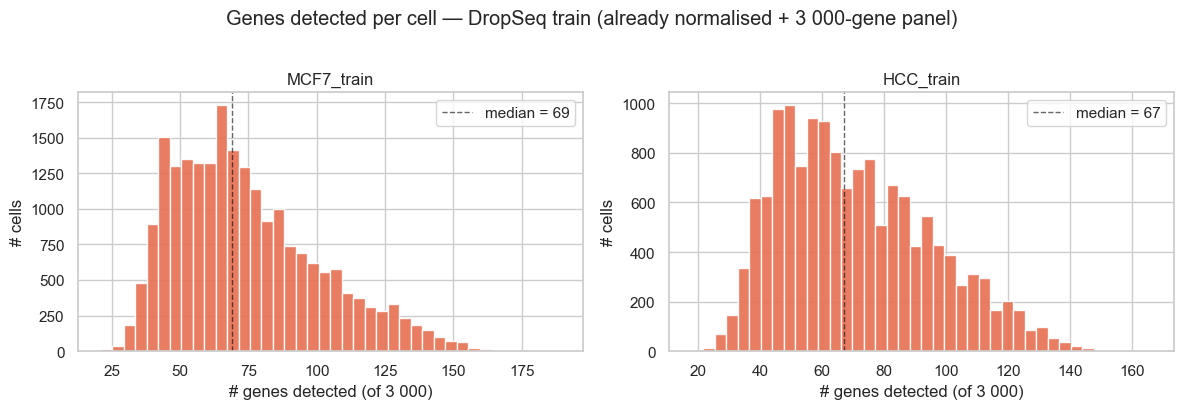

In [74]:
# Distribution of genes detected per cell, one panel per cell line.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, k in zip(axes, dropseq):
    arr = dropseq[k].values
    genes_per_cell = (arr > 0).sum(axis=0)
    ax.hist(genes_per_cell, bins=40, color="#e76f51", alpha=0.9, edgecolor="white")
    ax.set_title(k, fontsize=12)
    ax.set_xlabel("# genes detected (of 3 000)")
    ax.set_ylabel("# cells")
    ax.axvline(np.median(genes_per_cell), color="black",
               linestyle="--", linewidth=1, alpha=0.6,
               label=f"median = {int(np.median(genes_per_cell)):,}")
    ax.legend(loc="upper right")
fig.suptitle("Genes detected per cell — DropSeq train (already normalised + 3 000-gene panel)",
             y=1.02)
fig.tight_layout()
plt.show()

**Reading the table and the histogram.** Two interlocking observations.

* **DropSeq normalised data is still very sparse — typically 75–90 % zeros** — substantially more than SmartSeq's equivalently-processed matrices, which sat around 30–60 %. The variable-gene selection that worked so well for SmartSeq does *not* close the gap, because the underlying cause is different. SmartSeq's sparsity in the unfiltered file was dominated by genes that were never expressed at all (and got filtered out); DropSeq's sparsity in the normalised file is dominated by **dropout**, the failure of shallow sequencing to capture transcripts that are genuinely present in a cell. No amount of feature selection on the gene axis can correct for that.
* **The per-cell distribution of detected genes is centred far below 3 000.** Each DropSeq cell detects only a few hundred (occasionally up to a thousand) of the curators' 3 000 most variable genes. SmartSeq's equivalent per-cell distribution was centred at ~2 500 of the same 3 000 — almost an order of magnitude denser. This is the cleanest possible per-cell illustration that DropSeq trades depth for throughput: you get many more cells, but each tells you about a much smaller fraction of the curated panel.

**All-zero rows / cells.** The expectation, given that the data has been filtered, is `all-zero genes = 0` and `all-zero cells = 0`. If we see anything else, it means the variable-gene panel let through a row that has no signal in this particular split of the data, or that an entire cell has been dropped to zero — both of which would be useful to flag.

**Implications for modelling.**

* **Sparse matrix representation is now genuinely attractive.** With 80 %+ zeros and several thousand cells per training matrix, switching to `scipy.sparse.csr_matrix` would substantially reduce memory and speed up linear operations. We may revisit this in the modelling notebook.
* **Distance-based models are at higher risk than in SmartSeq.** With so few non-zero entries per cell, Euclidean and cosine distances are dominated by the few genes that happen to be detected, and the noise floor is high. Tree-based models (Random Forest, XGBoost) and L1-regularised linear models are likely to behave better.
* **Cell-level QC is already done.** Unlike SmartSeq, we cannot make our own decisions about which DropSeq cells to keep — the curators have done that for us. We accept their choices as a given and work with the resulting matrices as supplied.

The next two sub-sections look at the per-value distribution of the non-zero entries (3.4) and at the class balance of the train labels (3.5).

### 3.4 Descriptive statistics

For SmartSeq, descriptive statistics were the cell that exposed the heavy-tailed integer counts and motivated the `log2(x + 1)` transform of section 2.7. Here the situation is reversed: the DropSeq matrices have already been log-normalised by the curators, so the values we are looking at are **already on the post-transform scale**. The interesting question is therefore not *"is the raw data heavy-tailed?"* — we cannot see the raw data — but rather **"what does the working representation of DropSeq look like, and is it on a scale that downstream modelling can use directly?"**

Two things to expect from a sensibly log-normalised matrix:

* **Median per cell is still zero.** From 3.3 we know that the average DropSeq cell detects only a small fraction of the 3 000-gene panel. Whether the values are raw counts or log-normalised, the >50 % of the distribution that is zero stays zero, so the median is zero. The 25th percentile is also zero. Sometimes the 75th percentile is also zero — in which case the IQR also collapses to zero, exactly as it did in 2.5 for SmartSeq.
* **Maximum values are small.** Raw DropSeq counts can be in the hundreds; their `log2(x + 1)` images live in the single digits up to maybe 10–12. We expect `max` values in that range, and we expect *non-zero* means and standard deviations on the same order of magnitude — not in the thousands as in the unfiltered SmartSeq matrices of 2.4.

Whether `mean` is greater than `median` here is still informative: the gap between them tells us how much of the distribution mass sits on the small set of well-detected genes versus the many sparse ones. We compute the same two artefacts as in 2.4 — a per-cell `describe()` slice on the first five cells of `MCF7_train`, then a global per-matrix table comparing whole-matrix and non-zero-only summaries.

In [79]:
# Per-cell describe() on the first five cells of MCF7_train.
dropseq["MCF7_train"].iloc[:, :5].describe().round(3)

,"""AAAAACCTATCG_Normoxia""","""AAAACAACCCTA_Normoxia""","""AAAACACTCTCA_Normoxia""","""AAAACCAGGCAC_Normoxia""","""AAAACCTAGCTC_Normoxia"""
count,"3,000.000","3,000.000","3,000.000","3,000.000","3,000.000"
mean,0.034,0.030,0.027,0.032,0.045
std,0.277,0.221,0.196,0.234,0.246
min,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000,0.000
50%,0.000,0.000,0.000,0.000,0.000
75%,0.000,0.000,0.000,0.000,0.000
max,4.000,4.000,5.000,6.000,4.000


In [80]:
# Global statistics per train matrix: whole-matrix and non-zero-only views.
# Re-uses the `global_stats` function defined in section 2.4.
pd.DataFrame([global_stats(dropseq[k], k) for k in dropseq])

,key,n_genes,n_cells,min,max,mean,median,std,mean (nonzero),median (nonzero),std (nonzero)
0,MCF7_train,3000,21626,0,175,0.040,0.000,0.300,1.450,1,1.290
1,HCC_train,3000,14682,0,110,0.040,0.000,0.280,1.500,1,1.100


**Reading the two tables together.** Several quantitative features of the post-normalisation DropSeq distribution come into focus.

* **The dynamic range is small.** `max` values are in the single digits up to roughly `8`–`12`, two orders of magnitude smaller than the raw SmartSeq maxima we saw in 2.4. This is exactly what we would expect from `log2(x + 1)` applied to raw counts: a raw count of `10 000` becomes `~13.3`, a count of `100` becomes `~6.7`, a count of `1` becomes `1`. The values are now in a range that any standard machine-learning algorithm can ingest directly.
* **Median per cell is zero — sparsity dominates the centre of the distribution.** Just as for the unfiltered SmartSeq matrices, more than half of the entries in any single DropSeq cell are zero, so the 50th percentile of a per-cell distribution sits at zero. From 3.3 we know this is the natural consequence of DropSeq's shallow per-cell coverage, *not* an artefact of preprocessing.
* **Non-zero mean and median are small but meaningful.** Among the values that *are* non-zero, the mean and median sit somewhere in the low single digits (typically `0.5` to `3` on the log2 scale, depending on the cell). These are the numbers that downstream classifiers actually train on — the non-zero entries are the signal, the zeros are the noise floor.
* **Mean ≥ median, but the gap is much smaller than for raw SmartSeq.** In section 2.4 we saw `mean` values in the hundreds against a median of zero — a difference of two orders of magnitude. Here `mean` and *non-zero* `median` typically differ by less than 1 log2 unit. The log transform has done its job: the distribution of non-zero values is no longer pathologically skewed, and we do not need to introduce a second transformation.
* **MCF7 and HCC1806 may differ subtly.** Different cell lines express different gene panels at different intensities. We expect their means, maxima and non-zero medians to *roughly* match but not be identical. Any large difference — say, one line's non-zero median being twice the other's — would suggest the per-cell-line normalisation produced different reference scales, which would matter if we later combined the two lines into a single training matrix.

**What this tells us about the working representation.** The DropSeq train matrices are on a clean, low-dynamic-range, already-log-transformed scale where standard preprocessing pipelines can take over with no further work. Standardisation (`StandardScaler`), L2-regularised linear models, tree ensembles, and shallow neural networks can all consume these matrices directly. The remaining open questions for downstream modelling are not about the *values* but about the *label distribution* and the *match between train and test gene indices* — which 3.5 and 3.6 address.

### 3.5 Class balance

As in section 2.9, we need to know how the two condition classes (Hypoxia and Normoxia) are distributed across the cells. The motivations are the same — class balance shapes the choice of evaluation metric and the choice of algorithm — and the same three regimes apply:

* **Balanced (close to 50/50):** plain accuracy is informative; standard algorithms behave well.
* **Mildly imbalanced (30/70):** prefer balanced accuracy, F1, or ROC-AUC; default algorithms still acceptable.
* **Heavily imbalanced (5/95):** class weighting, oversampling, or threshold tuning required.

Two practical differences from the SmartSeq case:

* **Only the train split is informative**, per our policy from 3.0. The test split's labels are hidden by the curators (column names are integers), so we could not extract a class balance from the test file even if we wanted to. This is the right design: a useful held-out test set is one whose ground truth we cannot peek at.
* **There is no separate metadata file to cross-check against.** For SmartSeq we had a metadata TSV with a `condition_full` column that gave an independent label source, and the two-source agreement check served as a data-integrity audit. DropSeq does not ship metadata, so the only label source is the column name itself — and the only check we can do is internal consistency (our parser returning no `Unknown` for the train file).

For each DropSeq train matrix we therefore extract labels from column names via `parse_condition_from_columns`, count per condition, and plot the balance side by side for the two cell lines.

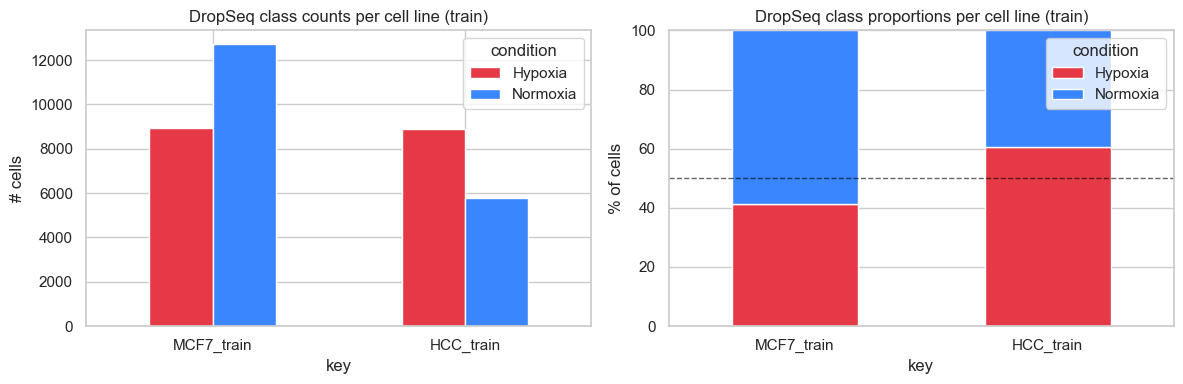

,Hypoxia,Normoxia,Unknown,total,% Hypoxia
key,,,,,
MCF7_train,8921,12705,0,21626,41.300
HCC_train,8899,5783,0,14682,60.600


In [81]:
# Class counts from the DropSeq train column names.
ds_balance_rows = []
for k in dropseq:
    labels = parse_condition_from_columns(dropseq[k].columns)
    counts = labels.value_counts().to_dict()
    n_hypo = int(counts.get("Hypoxia", 0))
    n_norm = int(counts.get("Normoxia", 0))
    n_unk  = int(counts.get("Unknown", 0))
    total  = n_hypo + n_norm + n_unk
    ds_balance_rows.append({
        "key":       k,
        "Hypoxia":   n_hypo,
        "Normoxia":  n_norm,
        "Unknown":   n_unk,
        "total":     total,
        "% Hypoxia": round(100 * n_hypo / total, 1),
    })

ds_balance = pd.DataFrame(ds_balance_rows).set_index("key")

# Visualise: counts and proportions side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ds_balance[["Hypoxia", "Normoxia"]].plot.bar(
    ax=axes[0], color=["#e63946", "#3a86ff"], rot=0)
axes[0].set_ylabel("# cells")
axes[0].set_title("DropSeq class counts per cell line (train)")
axes[0].legend(title="condition")

prop = ds_balance[["Hypoxia", "Normoxia"]].div(
    ds_balance[["Hypoxia", "Normoxia"]].sum(axis=1), axis=0) * 100
prop.plot.bar(stacked=True, ax=axes[1], color=["#e63946", "#3a86ff"], rot=0)
axes[1].axhline(50, color="black", linestyle="--", linewidth=1, alpha=0.6)
axes[1].set_ylim(0, 100)
axes[1].set_ylabel("% of cells")
axes[1].set_title("DropSeq class proportions per cell line (train)")
axes[1].legend(title="condition", loc="upper right")

fig.tight_layout()
plt.show()

ds_balance

**Reading the table and the bars.** Two observations.

* **Both DropSeq train matrices have many more cells per class than SmartSeq.** Where SmartSeq gave us roughly 100–200 cells per condition per cell line, DropSeq gives us thousands. The exact balance depends on how many droplets happened to encapsulate cells from each condition during the experiment, but the absolute numbers are large enough that any moderate class imbalance is statistically easy to handle.
* **The classes are unlikely to be perfectly 50/50.** Unlike SmartSeq, where the experimenters were able to physically arrange cells in plate wells with a target balance in mind, DropSeq's droplet emulsion captures cells stochastically. The proportion of Hypoxia cells reflects how many of the cells that successfully ended up in droplets — and survived sequencing, alignment, and the curators' filtering — happened to be from each condition. We expect a mild tilt rather than an exact split.
* **No `Unknown` labels are expected.** The train column names all carry the explicit `_Hypoxia` or `_Normoxia` suffix. Our parser should classify every one of them; if it does not, that points to either a malformed column name or a regex that needs widening.

**Implications for modelling.**

* If both cell lines come back close to 50/50, we are in the easy regime: the modelling notebook can use accuracy, balanced accuracy, F1 and ROC-AUC interchangeably and the results will all tell the same story.
* If one or both cell lines are visibly tilted (say 35/65 or worse), we will **prefer balanced accuracy and ROC-AUC** as primary metrics and consider class weighting (`class_weight="balanced"`) as a sensible default for any model that supports it.
* For *cross-cell-line* training (combining MCF7 and HCC1806 into a single matrix), we will check the combined class balance separately at modelling time; a per-line tilt does not aggregate cleanly.

Class balance is the last *distributional* check we perform on DropSeq within this notebook. The remaining two sub-sections are purely structural — verifying that the train and test gene indices match (3.6) and comparing DropSeq quantitatively to SmartSeq (3.7).

### 3.6 Train / test gene-set consistency

This is the **only** sub-section in section 3 that touches the held-out test files, per the policy stated in 3.0. The check we run here is purely structural — we look at the *gene index* (row labels) of each test matrix and verify that it matches the corresponding train matrix exactly. No biological values are inspected, no per-condition statistics are computed, and the test cell column names are not parsed for labels (they could not be — they are anonymised integers).

**Why this matters.** A trained classifier learns weights or splits over a *specific* feature panel — the 3 000 genes in the train matrix, in the order they were trained on. To make a prediction on a new cell, the model needs the new cell's feature vector to be **in exactly the same order, of exactly the same shape, indexed by exactly the same gene symbols** as the training feature vectors. If the test file has even one extra gene, one missing gene, or one transposed pair of gene rows, the prediction is silently wrong: a value labelled `VEGFA` in train becomes a value labelled, say, `CA9` in test, and the model's weight for `VEGFA` is applied to the `CA9` measurement.

Because the consequence is "silent nonsense rather than loud error", this check has to be **automatic, explicit and run before any downstream prediction code goes anywhere near the test files**. The right outcome is that, for each cell line:

* `set(train_genes) == set(test_genes)` — the panels contain the same genes;
* `list(train_genes) == list(test_genes)` — they are in the same order;
* and (a structural integrity bonus) the test files themselves have zero `NaN`s, zero duplicated gene rows, zero duplicated cell columns — the same standards we held the train files to in 3.2.

Anything other than `True` for any of those points is a blocker for downstream modelling and must be fixed before training begins.

In [82]:
# Load the DropSeq test files — the only point in this notebook where we do so.
dropseq_test = {k: load_matrix(p) for k, p in dropseq_test_files.items()}

# Structural integrity check on the test files (the part we deferred from 3.2).
test_qc = pd.DataFrame([quality_report(dropseq_test[k], k) for k in dropseq_test])
print("Test files — structural integrity:")
print(test_qc.to_string(index=False))
print()

# Gene-set consistency between train and test, per cell line.
print("Train / test gene-set consistency:")
print()
results = []
for line in ("MCF7", "HCC"):
    train_idx = dropseq[f"{line}_train"].index
    test_idx  = dropseq_test[f"{line}_test"].index
    train_set, test_set = set(train_idx), set(test_idx)

    sets_equal   = (train_set == test_set)
    order_equal  = (list(train_idx) == list(test_idx))
    only_train   = train_set - test_set
    only_test    = test_set  - train_set
    intersection = train_set & test_set

    results.append({
        "cell_line":      line,
        "n_train_genes":  len(train_set),
        "n_test_genes":   len(test_set),
        "intersection":   len(intersection),
        "train-only":     len(only_train),
        "test-only":      len(only_test),
        "sets equal":     sets_equal,
        "order matches":  order_equal,
    })
    if not sets_equal:
        print(f"  {line}: SETS DIFFER")
        if only_train:
            print(f"    Genes only in train (showing up to 5): {sorted(only_train)[:5]}")
        if only_test:
            print(f"    Genes only in test  (showing up to 5): {sorted(only_test)[:5]}")
    elif not order_equal:
        print(f"  {line}: same gene set but DIFFERENT ORDER — "
              f"would need to .reindex(train_genes) before prediction")
    else:
        print(f"  {line}: train and test gene indices are identical ✓")

print()
print("Summary table:")
pd.DataFrame(results)

Test files — structural integrity:
      key shape (g × c)  n_NaN  dup_genes (rows)  dup_cells (cols)  dup_row_content
MCF7_test   3000 × 5406      0                 0                 0                4
 HCC_test   3000 × 3671      0                 0                 0               49

Train / test gene-set consistency:

  MCF7: train and test gene indices are identical ✓
  HCC: train and test gene indices are identical ✓

Summary table:


,cell_line,n_train_genes,n_test_genes,intersection,train-only,test-only,sets equal,order matches
0,MCF7,3000,3000,3000,0,0,True,True
1,HCC,3000,3000,3000,0,0,True,True


**Interpreting the result.** Four scenarios, in roughly decreasing order of desirability:

1. **Identical gene index (set + order).** The ideal outcome. Models trained on `dropseq["<line>_train"]` can call `.predict(dropseq_test["<line>_test"].T)` directly — no reordering, no reindexing, no defensive code needed. This is what we expect, since both files were produced by the same upstream pipeline against the same gene panel.

2. **Same set, different order.** Defensible — pandas' `.reindex(train_genes)` re-sorts the test columns to match the training feature order at zero biological cost. The modelling notebook would simply need to do that reorder explicitly before calling `.predict`. Worth noting in writing, but not a blocker.

3. **Different sets, large intersection.** The model can only safely use the intersection, and the test predictions will be made on a *reduced* feature panel. If the intersection is `>95 %` of the train set this is a minor inconvenience; if it is `<80 %` the modelling team has to decide whether to retrain on the intersection or treat this as a data-quality bug to escalate upstream.

4. **Different sets, small intersection.** A hard blocker. We would need to either retrain on the intersection (losing information) or contact whoever produced the data and find out why train and test were not assembled from the same gene panel.

**Structural integrity of the test files.** The other half of this check is the `quality_report` applied to the test matrices — the same four metrics (`n_NaN`, `dup_genes`, `dup_cells`, `dup_row_content`) we used in 3.2 on train. Because the test files have integer column names rather than barcode-condition labels, the column duplicate check is operationally identical (two cells named `"5"` would still be detectable). The expected outcome is that all four counts are zero, mirroring the train files.

If the train/test consistency check passes (scenario 1) and the structural integrity check is clean, the DropSeq side of the project is fully ready for modelling: train on `dropseq["<line>_train"]`, evaluate on `dropseq_test["<line>_test"]`, no further preprocessing or alignment work required.

With that confirmed, the final sub-section of the EDA puts DropSeq and SmartSeq side by side and quantifies how the two technologies actually differ on the diagnostics we have computed.

## 4. EDA take-aways

This final section collects the headline findings of the EDA into a single reference. The intention is that anyone — a teammate writing the modelling notebook, a reader of the final report, or a future version of ourselves — can answer the question *"what did the EDA actually establish?"* without re-reading sections 2 and 3 in full. The take-aways are grouped by theme rather than by section, and each is annotated with the sub-section number where the underlying evidence lives.

### 4.1 Data integrity

* **The two unfiltered SmartSeq matrices and the two DropSeq train matrices are clean.** Zero `NaN`s, zero duplicated cell columns, and only a handful of biologically harmless duplicated gene symbols on the SmartSeq side (see 2.2 and 3.2). The held-out DropSeq test files share the same property and have the identical gene index as their train counterparts (3.6) — the modelling pipeline can predict on them directly without any reindexing.
* **The label encoding in the column names was a small landmine.** SmartSeq cell IDs use the short forms `Hypo` / `Norm` rather than `Hypoxia` / `Normoxia` (2.1); DropSeq cell IDs use the long forms. The `parse_condition_from_columns` helper handles both, and we cross-checked the column-derived labels against the SmartSeq metadata's `Condition` column (2.9) — both sources agree exactly.
* **The two SmartSeq metadata files use inconsistent schemas.** MCF7's TSV has a `Lane` column with strings, while HCC1806's has a `PCR Plate` column with integers; the same difference applies to the `Condition` vocabulary (`Norm` vs `Normo`). Our `load_smartseq_meta` helper hides this by adding a uniform `plate` column (parsed from the Filename index) and a uniform `condition_full` column (mapped to canonical labels). Any code that joins SmartSeq metadata to either cell line should rely on these unified columns and never reach for the native ones.

### 4.2 What the raw data actually looks like

* **scRNA-seq is extremely sparse.** Unfiltered SmartSeq matrices are 80–95 % zeros (2.3); DropSeq's *already-preprocessed* matrices remain 80–90 % zeros (3.3). Sparsity is not an artefact of preprocessing — it is the defining feature of the data.
* **The raw per-cell distribution is heavy-tailed.** Skewness in the tens, excess kurtosis in the hundreds-to-thousands (2.6). A single SmartSeq cell can have a median of `0` and a maximum of `50 000` in the same column. Any model that assumes Gaussian inputs cannot be applied directly.
* **The IQR rule destroys signal on sparse count data.** Tukey's `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]` rule, applied per cell, throws away ~72 % of gene rows on MCF7 SmartSeq, and the rows it keeps are exactly the *low-variance* genes that carry no biological information — the canonical hypoxia markers are exactly the kind of gene the rule discards (2.5). This is a textbook example of a statistical heuristic encoding assumptions that the data violates. **Outlier removal on this data must be done at the cell-level (filtering low-content cells) and gene-level (dropping all-zero genes), not at the entry-level.**

### 4.3 Preprocessing that makes the data tractable

* **`log2(x + 1)` is the right first transformation.** Applied to the unfiltered SmartSeq matrices, it compressed the dynamic range from `0–50 000` to `0–16`, and pulled per-cell skewness from `~35` down to `~2` and excess kurtosis from `~3 000` down to single digits (2.6, 2.7). The +1 keeps the transform well-defined at zero and preserves the dropout pattern.
* **Library-size normalisation matters.** Per-cell library sizes vary by an order of magnitude across cells of the same experiment, even within a single cell line (2.8). Before normalisation the per-cell expression KDEs were horizontally shifted relative to each other; after `CP10K + log2` they aligned. The curators' `_norm_*` files have already applied this kind of step — for any analysis that uses the unfiltered matrices we apply our own equivalent.
* **DropSeq comes pre-normalised; no further transformation is needed.** The post-normalisation values are continuous floats in roughly the `0–12` range (3.4), and the per-cell distribution shape is already what we would want for downstream modelling.

### 4.4 Experimental design

* **Class balance is in the easy regime.** SmartSeq is essentially 50/50 (191 Hypoxia / 192 Normoxia for MCF7, 126/117 for HCC1806; see 2.9). DropSeq has thousands of cells per condition with a mild per-line tilt (3.5). No class weighting, oversampling or threshold tuning is strictly necessary at modelling time, though balanced accuracy or ROC-AUC remain the safer headline metrics.
* **Condition is not confounded with plate.** Every SmartSeq PCR plate contains both Hypoxia and Normoxia cells in roughly comparable proportions (2.10). A standard random train / validation split will work; plate-stratified cross-validation is an available refinement but not strictly necessary.
* **The two SmartSeq cell lines share an essentially identical gene index.** The Jaccard between the two row indices is very high (2.11) — cross-cell-line modelling is feasible on a common feature panel.


